# Noise budget, 09-11 → 09-13 steady hold

44 h laser-driven hold (`LASER_OFFSET` = 1300, 5.8 mW at the chamber, rotor ~0.749 Hz;
dataset 1 of `analysis/dataset_20260911_drive_spindown.md`). One window (1–40 h), one set of constants.

| § | content | data |
|---|---|---|
| 1 | rotor frequency: extraction, estimator checks, primary noise PSD | LES |
| 2 | Pb-212 decay timescale in Fourier space | model |
| 3 | thermal noise floor | model |
| 4 | sensitivity: σ_f(T) → minimum torque and force | LES |
| 5 | laser RIN | PD |
| 6 | correlation: does PD wander drive the rotor? k = (δf/f)/(δP/P) | LES + PD |
| 7 | noise projection: laser vs measured vs thermal | LES + PD |
| 8 | step-down observations (reported only) | CSV |
| 9 | conclusions | |

**No power calibration:** RIN and k are fractional; the sensitivity uses only I, τ and σ_f.

**Supersedes `sensitivity_20260911.ipynb`** (kept as a record): I = 1.88e-11 (was 1.7e-11),
lever arm 1.38 mm wing centroid (was 1.88 mm tip), window 1–40 h (was 1–45 h). §4 reproduces
September's numbers with September's settings.

## 0. Constants and data

| | value | source |
|---|---|---|
| I | 1.88e-11 kg·m² | calculated disk + sail (`CLAUDE.md`, "calculated, never measured"); SolidWorks gives 1.7e-11, so ~10% systematic |
| τ | 79.8 min | free decay, `spindown_20260913.ipynb`; viscous law over 0.22–0.79 Hz confirmed in `damping_law_comparison.ipynb` |
| lever arm | 1.38 mm | SAL-001 wing centroid (uniform full-wing coating, 0.88–1.88 mm); tip = 1.88 mm |
| T_bath, NSIG | 300 K, 5 | as in July/September |

In [1]:
import os, numpy as np, h5py, pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import decimate, welch, csd, coherence, lfilter
from scipy.ndimage import uniform_filter1d

DATA = os.path.expanduser('~/Library/CloudStorage/Dropbox/Microspheres/TFINER/data')
GPS_A, GPS_B = 1473204000, 1473376497          # dataset 1: laser-driven hold
DARK_FILE = 'Y1_RDS-PD_IN1_DQ_1473375897_1473435502.h5'   # dataset 2: laser OFF from +600 s
DARK_SKIP_S = 700                               # s into dataset 2 (laser off at +600 s)
DIVISOR = 2                                     # rotation = LES line / 2 (confirmed 09-14)

I_TOTAL = 1.88e-11        # kg m^2
I_ALT   = 1.7e-11         # kg m^2, SolidWorks -- systematic only
TAU_S   = 79.8 * 60       # s
GAMMA   = 1 / TAU_S
R_EFF   = 1.38e-3         # m, wing centroid
R_TIP   = 1.88e-3         # m, wing tip
KB_J, T_BATH, NSIG = 1.380649e-23, 300.0, 5.0

WIN_H = (1, 40)           # analysis window, hours from file start

In [2]:
def load(path):
    """Segment-aware .h5 reader (as in sensitivity_20260911); checks for gaps."""
    with h5py.File(path, 'r') as f:
        y = np.asarray(f['data'], float)
        fs = float(f.attrs['sample_rate'])
        s = f['segments']
        g0, i0, L = s['gps_start'][:], s['index_start'][:], s['length'][:]
        t = np.empty(len(y))
        for a, b, c in zip(g0, i0, L):
            t[b:b + c] = a + np.arange(c) / fs
    gap = np.abs(np.diff(g0) - L[:-1] / fs).max() if len(g0) > 1 else 0
    print(f'{os.path.basename(path)}: {len(y)/fs/3600:.2f} h, {len(g0)} segments, max gap {gap:.3f} s')
    return y, t, fs

def to_1hz(y, t, fs):
    n = int(len(y) // fs * fs); k = int(fs)
    return y[:n].reshape(-1, k).mean(1), t[:n].reshape(-1, k).mean(1)

les, t_les, fs = load(f'{DATA}/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5')
pd_raw, t_pd, fs_pd = load(f'{DATA}/PD/Y1_RDS-PD_IN1_DQ_{GPS_A}_{GPS_B}.h5')
pd1, tpd1 = to_1hz(pd_raw, t_pd, fs_pd); del pd_raw, t_pd
dk_raw, t_dk, fs_dk = load(f'{DATA}/PD/{DARK_FILE}')
dk1, _ = to_1hz(dk_raw, t_dk, fs_dk); del dk_raw, t_dk
dark = dk1[DARK_SKIP_S:]
DARK_LEVEL = dark.mean()
print(f'dark PD: {DARK_LEVEL:.3f} counts (std {dark.std():.3f}) over {len(dark)/3600:.1f} h')

Y1_RDS-LES_YAW_IN1_DQ_1473204000_1473376497.h5: 47.92 h, 288 segments, max gap 0.000 s
Y1_RDS-PD_IN1_DQ_1473204000_1473376497.h5: 47.92 h, 288 segments, max gap 0.000 s
Y1_RDS-PD_IN1_DQ_1473375897_1473435502.h5: 16.56 h, 100 segments, max gap 0.000 s
dark PD: 1.794 counts (std 0.089) over 16.4 h


### 0.1 Is the PD seeing only the laser?

Raw 1024 Hz PD, two 1 h stretches (10 h, 30 h), searched at rotation harmonics (rotation from
the LES). Dark PD on the same scale. The y-axis is a density; line amplitudes are in the table.

- **Rotor light (dotted):** present, strongest at 2× rotation, but only ~0.1 ‰ of the PD signal
  (0.08 ‰ at 10 h, 0.12 ‰ at 30 h). Coherent with both LES axes (0.88–1.00).
- **Comb at 0.308 Hz and multiples (▼), not interpreted:** ~0.15 ‰; not a rotation harmonic
  (0.308/0.749 = 0.41); absent with the laser off (so not PD electronics, but laser vs reflected
  light not separable); absent in and incoherent with both LES axes (doesn't exclude a tilt mode:
  a specular reflection moves 2× the tilt); steady for 39 h, off at ~43.5–44.3 h, before the
  45.5 h jump. Where absent, the amplitude column is bin noise; use peak/floor. Origin open.
  Lines at 1.93 and 1.99 Hz unassigned.

**No effect downstream:** everything uses the PD averaged over 150 s windows or slower, which cuts
0.3–3 Hz lines by ≳100× (≲10⁻³ ‰ vs ~2 ‰ slow wander). A slowly drifting steady reflected
component isn't measured; by order of magnitude it is a few tenths of a ‰, below the 2 ‰ wander.

         data |      line | freq (Hz) | peak/floor | amp (permil of hold PD)
   PD 10-11 h |  1x f_rot |    0.7483 |         27 |                   0.021
   PD 10-11 h |  2x f_rot |    1.4983 |        729 |                   0.078
   PD 10-11 h |  3x f_rot |    2.2467 |         10 |                   0.009
   PD 10-11 h |  4x f_rot |    2.9967 |        372 |                   0.059
   PD 10-11 h |   1x comb |    0.3083 |        866 |                   0.157
   PD 10-11 h |   2x comb |    0.6167 |        778 |                   0.124
   PD 10-11 h |   3x comb |    0.9267 |        257 |                   0.064
   PD 10-11 h |   4x comb |    1.2350 |         61 |                   0.030
  YAW 10-11 h |   1x comb |    0.3100 |          2 |            (not in LES)
  PIT 10-11 h |   1x comb |    0.3100 |          2 |            (not in LES)
   PD 30-31 h |  1x f_rot |    0.7483 |        164 |                   0.042
   PD 30-31 h |  2x f_rot |    1.4983 |       2204 |                   0.120

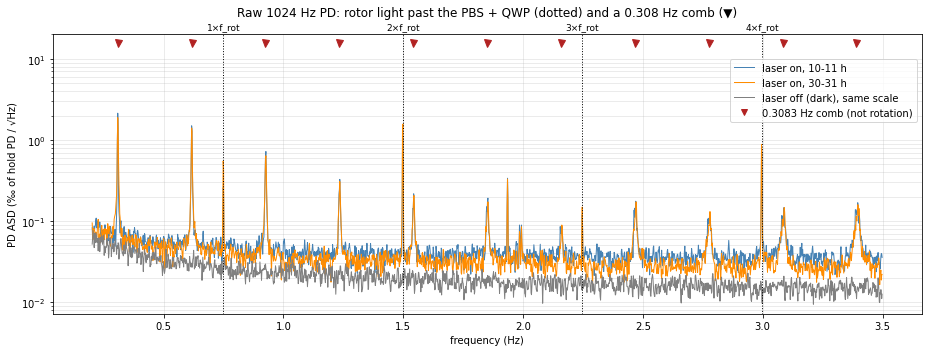


 hour | f_rot (Hz) | PD level | comb peak/floor | comb amp (permil)
  5.0 |     0.7492 |    470.6 |             620 |             0.145
 20.0 |     0.7492 |    470.4 |             881 |             0.161
 39.0 |     0.7492 |    472.0 |             665 |             0.151
 41.0 |     0.7492 |    439.5 |             180 |             0.108
 43.0 |     0.7483 |    407.2 |             408 |             0.120
 44.5 |     0.7483 |    404.9 |               2 |             0.036
 46.6 |     0.7883 |    390.0 |               3 |             0.062

 stretch | PD vs | coh @ 1x f_rot | coh @ 2x f_rot | coh @ comb
 10-11 h |   YAW |           0.88 |           0.99 |       0.04
 10-11 h |   PIT |           0.93 |           0.98 |       0.05
 30-31 h |   YAW |           0.99 |           1.00 |       0.29
 30-31 h |   PIT |           0.99 |           1.00 |       0.23
(~11 averages per stretch: coherence up to ~0.3 is consistent with noise)


In [3]:
LEAK_H = (10, 30)       # 1 h stretches, hours from file start (both inside 1-40 h)
N_HARM = 4              # harmonics to tabulate, of f_rot and of the 0.308 Hz comb

def raw_asd(path, h0, dur=3600, nps_s=600):
    """Welch PSD of a raw 1024 Hz stretch [h0, h0+dur) h from file start (no gaps, checked in load)."""
    with h5py.File(path, 'r') as f:
        fsr = float(f.attrs['sample_rate']); a = int(h0*3600*fsr)
        y = f['data'][a:a + int(dur*fsr)].astype(float)
    fw, P = welch(y - y.mean(), fsr, nperseg=int(nps_s*fsr))
    return fw, P, y.mean()

def line(fw, P, f0, lvl):
    """Strongest bin within +-10 mHz of f0: (freq, peak/local median, amplitude in permil of lvl)."""
    m = (fw > f0 - 0.01) & (fw < f0 + 0.01); j = np.flatnonzero(m)[np.argmax(P[m])]
    amp = np.sqrt(2*P[j-2:j+3].sum()*(fw[1] - fw[0]))       # sinusoid amplitude, +-2 bins
    return fw[j], P[j]/np.median(P[max(j-200, 0):j+200]), amp/lvl*1e3

PD_HOLD = f'{DATA}/PD/Y1_RDS-PD_IN1_DQ_{GPS_A}_{GPS_B}.h5'
LES_HOLD = f'{DATA}/LES_yaw/Y1_RDS-LES_YAW_IN1_DQ_{GPS_A}_{GPS_B}.h5'
PIT_HOLD = f'{DATA}/LES_pit/Y1_RDS-LES_PIT_IN1_DQ_{GPS_A}_{GPS_B}.h5'
F_COMB = 0.3083         # Hz, comb fundamental (Welch peak, 1.7 mHz bins; same at 10 h and 30 h)

fig, ax = plt.subplots(figsize=(13, 5))
print(f"{'data':>13} | {'line':>9} | {'freq (Hz)':>9} | {'peak/floor':>10} | {'amp (permil of hold PD)':>23}")
for h0, col in zip(LEAK_H, ('steelblue', 'darkorange')):
    fw, P, lvl = raw_asd(PD_HOLD, h0)
    lvl -= DARK_LEVEL
    fl, Pl, _ = raw_asd(LES_HOLD, h0)
    ml = (fl > 1.3) & (fl < 1.7); f_rot = fl[ml][np.argmax(Pl[ml])]/DIVISOR   # rotation from the LES line
    m = (fw > 0.2) & (fw < 3.5)
    ax.semilogy(fw[m], np.sqrt(P[m])/lvl*1e3, color=col, lw=1, label=f'laser on, {h0}-{h0+1} h')
    for name, f0 in [(f'{n}x f_rot', n*f_rot) for n in range(1, N_HARM+1)] + \
                    [(f'{n}x comb', n*F_COMB) for n in range(1, N_HARM+1)]:
        fj, pf, a = line(fw, P, f0, lvl)
        print(f'{"PD "+str(h0)+"-"+str(h0+1)+" h":>13} | {name:>9} | {fj:9.4f} | {pf:10.0f} | {a:23.3f}')
    for ch, (fq, Pq) in (('YAW', (fl, Pl)), ('PIT', raw_asd(PIT_HOLD, h0)[:2])):   # rotor motion, x and y
        fj, pf, _ = line(fq, Pq, F_COMB, 1)
        print(f'{ch+" "+str(h0)+"-"+str(h0+1)+" h":>13} | {"1x comb":>9} | {fj:9.4f} | {pf:10.0f} | {"(not in LES)" if pf < 10 else "PRESENT":>23}')

# laser off: same raw channel, 2-3 h into dataset 2, normalised to the HOLD PD level so it is directly comparable
fw, P, _ = raw_asd(f'{DATA}/PD/{DARK_FILE}', 2)
m = (fw > 0.2) & (fw < 3.5)
ax.semilogy(fw[m], np.sqrt(P[m])/lvl*1e3, color='gray', lw=1, label='laser off (dark), same scale')
for n in range(1, N_HARM+1):
    fj, pf, a = line(fw, P, n*F_COMB, lvl)
    print(f'{"dark":>13} | {f"{n}x comb":>9} | {fj:9.4f} | {pf:10.0f} | {a:23.3f}')

for n in range(1, N_HARM+1):
    ax.axvline(n*f_rot, color='k', ls=':', lw=1)
    ax.text(n*f_rot, 1.01, f'{n}×f_rot', transform=ax.get_xaxis_transform(), ha='center', va='bottom', fontsize=9)
for n in range(1, int(3.5/F_COMB) + 1):   # the comb runs to the plot edge
    ax.plot(n*F_COMB, 0.97, 'v', color='firebrick', ms=7, transform=ax.get_xaxis_transform())
ax.plot([], [], 'v', color='firebrick', label=f'{F_COMB} Hz comb (not rotation)')
ax.set_xlabel('frequency (Hz)'); ax.set_ylabel('PD ASD (‰ of hold PD / √Hz)')
ax.set_title('Raw 1024 Hz PD: rotor light past the PBS + QWP (dotted) and a 0.308 Hz comb (▼)', pad=18)
ax.set_ylim(top=20); ax.legend(loc='upper right', bbox_to_anchor=(1, 0.93)); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

# when does the comb switch off? 30 min stretches; f_rot from the LES line
print(f"\n{'hour':>5} | {'f_rot (Hz)':>10} | {'PD level':>8} | {'comb peak/floor':>15} | {'comb amp (permil)':>17}")
for h0 in (5, 20, 39, 41, 43, 44.5, 46.6):
    fw, P, lvl = raw_asd(PD_HOLD, h0, dur=1800); lvl -= DARK_LEVEL
    fl, Pl, _ = raw_asd(LES_HOLD, h0, dur=1800)
    ml = (fl > 1.3) & (fl < 1.7); f_rot = fl[ml][np.argmax(Pl[ml])]/DIVISOR
    _, pf, a = line(fw, P, F_COMB, lvl)
    print(f'{h0:5.1f} | {f_rot:10.4f} | {lvl:8.1f} | {pf:15.0f} | {a:17.3f}')

# are the PD's rotor lines really rotor light? coherence with both LES axes (16 Hz is plenty below 3 Hz)
def raw16(path, h0, dur=3600):
    """Raw stretch decimated 1024 -> 16 Hz (FIR anti-alias)."""
    with h5py.File(path, 'r') as f:
        a = int(h0*3600*1024); y = f['data'][a:a + int(dur*1024)].astype(float)
    return decimate(decimate(y - y.mean(), 8, ftype='fir'), 8, ftype='fir')

print(f"\n{'stretch':>8} | {'PD vs':>5} | {'coh @ 1x f_rot':>14} | {'coh @ 2x f_rot':>14} | {'coh @ comb':>10}")
for h0 in LEAK_H:
    pd16, yaw16 = raw16(PD_HOLD, h0), raw16(LES_HOLD, h0)
    fq, Pq = welch(yaw16, fs=16, nperseg=16*600)
    mq = (fq > 1.3) & (fq < 1.7); f_rot = fq[mq][np.argmax(Pq[mq])]/DIVISOR
    for ch, sig in (('YAW', yaw16), ('PIT', raw16(PIT_HOLD, h0))):
        fc, C = coherence(pd16, sig, fs=16, nperseg=16*600)
        at = lambda f0: C[np.abs(fc - f0) < 0.003].max()
        print(f'{h0:3d}-{h0+1:<3d}h | {ch:>5} | {at(f_rot):14.2f} | {at(2*f_rot):14.2f} | {at(F_COMB):10.2f}')
print('(~11 averages per stretch: coherence up to ~0.3 is consistent with noise)')

## 1. Rotor frequency

### 1.1 Frequency track

Tracker from `sensitivity_20260911.ipynb`: LES decimated to 16 Hz; 150 s Hann windows every 60 s;
largest FFT peak in a band (0.85–1.10×) re-centred on the last estimate; rotor = LES line / 2.
Two estimates per window, from the same peak bin i:

- `FR_RAW`: bin frequency fr[i], no interpolation;
- `FR`: fr[i] + three-point parabolic correction (the September method). **Primary.**

Tracking and SNR use `FR`, as before.

fs = 16 Hz, window 150 s = 2400 samples, step 60 s
bin spacing: df_optical = 1/150 s = 0.006667 Hz, df_rotor = 1/(2x150 s) = 0.003333 Hz
2873 estimates, FR 0.4125..0.7889 Hz, median SNR 622


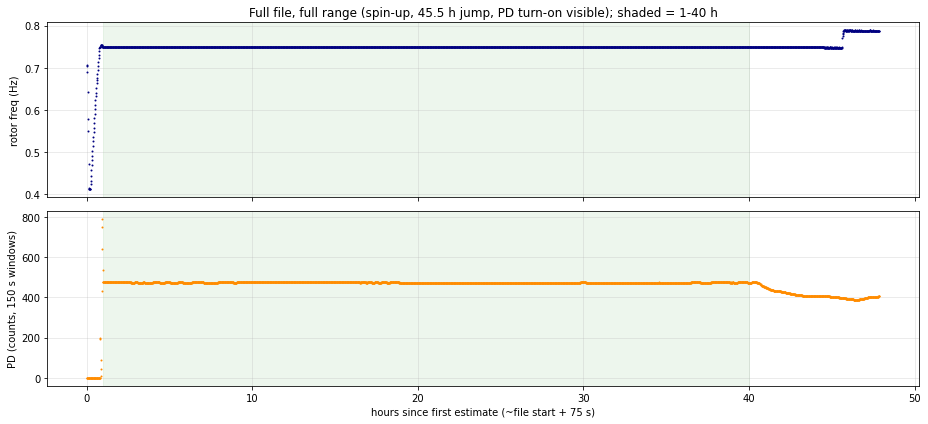

In [4]:
def peak_in_band(x, fsx, lo, hi):
    """Largest Hann-windowed FFT peak in (lo, hi). Returns (f_raw, f_interp, snr):
    f_raw is the peak bin's frequency fr[i]; f_interp adds the three-point parabolic correction."""
    ac = x - x.mean()
    X = np.abs(np.fft.rfft(ac*np.hanning(len(ac))))
    fr = np.fft.rfftfreq(len(ac), 1/fsx)
    m = (fr > lo) & (fr < hi)
    if not m.any(): return np.nan, np.nan, 0.0
    i = np.flatnonzero(m)[np.argmax(X[m])]
    if i == 0 or i >= len(X)-1: return fr[i], fr[i], 0.0
    y0, y1, y2 = X[i-1], X[i], X[i+1]
    den = y0 - 2*y1 + y2
    fpk = fr[i] + (0.5*(y0-y2)/den if den else 0)*(fr[1]-fr[0])
    snr = X[i]/(np.median(X[max(0,i-60):i+60]) or 1)
    return fr[i], fpk, snr

y16 = decimate(decimate(les - les.mean(), 8, ftype='fir'), 8, ftype='fir')
fs16 = fs/64
t16 = t_les[0] + np.arange(len(y16))/fs16
T_FILE0 = t_les[0]; del les, t_les

WIN, STEP = 150.0, 60.0
nw, sw = int(WIN*fs16), int(STEP*fs16)
DF_OPT = fs16/nw                # FFT bin spacing of one window, in LES (optical) frequency
DF_ROT = DF_OPT/DIVISOR         # the same bin spacing expressed as rotor frequency
print(f'fs = {fs16:g} Hz, window {WIN:.0f} s = {nw} samples, step {STEP:.0f} s')
print(f'bin spacing: df_optical = 1/{WIN:.0f} s = {DF_OPT:.6f} Hz, '
      f'df_rotor = 1/({DIVISOR}x{WIN:.0f} s) = {DF_ROT:.6f} Hz')

rows, track = [], 1.50
for i in range(0, len(y16)-nw, sw):
    tc = t16[i] + WIN/2
    fraw, fpk, snr = peak_in_band(y16[i:i+nw], fs16, max(track*0.85, 0.02), track*1.10)
    if np.isnan(fpk) or fpk <= 0: continue
    rows.append((tc, fraw/DIVISOR, fpk/DIVISOR, snr))
    track = fpk
T, FR_RAW, FR, SNR = map(np.array, zip(*rows))
T_REF = T[0]                  # hours are counted from the first tracker estimate (as in September)
H_ALL = (T - T_REF)/3600
print(f'{len(T)} estimates, FR {FR.min():.4f}..{FR.max():.4f} Hz, median SNR {np.median(SNR):.0f}')

# PD averaged over exactly the same 150 s windows -> one shared time grid for section 6
PDW = np.array([pd1[(tpd1 >= tc - WIN/2) & (tpd1 < tc + WIN/2)].mean() for tc in T])

fig, ax = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
ax[0].plot(H_ALL, FR, '.', ms=2, color='navy'); ax[0].set_ylabel('rotor freq (Hz)')
ax[1].plot(H_ALL, PDW, '.', ms=2, color='darkorange'); ax[1].set_ylabel('PD (counts, 150 s windows)')
for a in ax:
    a.axvspan(*WIN_H, color='green', alpha=0.07); a.grid(alpha=.3)
ax[1].set_xlabel('hours since first estimate (~file start + 75 s)')
ax[0].set_title(f'Full file, full range (spin-up, 45.5 h jump, PD turn-on visible); shaded = {WIN_H[0]}-{WIN_H[1]} h')
plt.tight_layout(); plt.show()

### 1.2 Analysis window: 1–40 h

After 40 h the operating point isn't stationary: the PD slides ~15% from 40.5 h, the frequency dips
~0.7 mHz in 43–45 h and jumps to ~0.788 Hz at 45.5 h (none investigated here). `mref` selects
1–40 h (hours from the first estimate) and is used throughout. The 2 h blocks: steady over 1–41 h.

In [5]:
mref = (H_ALL >= WIN_H[0]) & (H_ALL <= WIN_H[1])   # the 1-40 h analysis window, used throughout

print(f"{'hours':>7} | {'mean f (Hz)':>11} | {'std (mHz)':>9} | {'mean PD':>8}")
for a in range(1, 47, 2):
    m = (H_ALL >= a) & (H_ALL < a+2)
    print(f'{a:3d}-{a+2:<3d} | {FR[m].mean():11.5f} | {FR[m].std()*1e3:9.3f} | {PDW[m].mean():8.1f}')

  hours | mean f (Hz) | std (mHz) |  mean PD
  1-3   |     0.74897 |     0.101 |    475.4
  3-5   |     0.74898 |     0.111 |    473.5
  5-7   |     0.74887 |     0.110 |    473.6
  7-9   |     0.74900 |     0.134 |    473.5
  9-11  |     0.74915 |     0.068 |    474.3
 11-13  |     0.74908 |     0.080 |    474.9
 13-15  |     0.74902 |     0.084 |    475.7
 15-17  |     0.74901 |     0.083 |    475.1
 17-19  |     0.74897 |     0.090 |    474.6
 19-21  |     0.74903 |     0.113 |    472.7
 21-23  |     0.74914 |     0.092 |    473.2
 23-25  |     0.74910 |     0.092 |    472.7
 25-27  |     0.74908 |     0.080 |    473.2
 27-29  |     0.74908 |     0.084 |    473.0
 29-31  |     0.74906 |     0.065 |    473.4
 31-33  |     0.74907 |     0.073 |    473.2
 33-35  |     0.74906 |     0.075 |    473.4
 35-37  |     0.74909 |     0.078 |    473.6
 37-39  |     0.74908 |     0.096 |    473.9
 39-41  |     0.74910 |     0.083 |    470.9
 41-43  |     0.74904 |     0.151 |    427.5
 43-45  | 

### 1.3 Estimator check: raw bin vs parabolic interpolation

Does the interpolation create the ~0.1 mHz wander? Compare `FR_RAW` (A) with `FR` (B).

| | value | meaning |
|---|---|---|
| optical line | ~1.498 Hz | LES peak (two wings → two per turn) |
| f_rotor | ~0.749 Hz | optical / 2; the tracked quantity |
| df | 6.67 mHz optical, 3.33 mHz rotor | bin spacing of a 150 s window: step between A's possible *values* |
| ν | ~65 µHz – 8.3 mHz | Fourier frequency of the fluctuations: how *fast* f_rotor wanders |

df resolves the value of f; ν is its rate of change. Unrelated axes.

In [6]:
fA, fB, h11 = FR_RAW[mref], FR[mref], H_ALL[mref]      # 1-40 h (mref from 1.2)
dAB = fB - fA
print(f'bin spacing: df_optical = {DF_OPT:.6f} Hz, df_rotor = {DF_ROT:.6f} Hz')
print(f'{WIN_H[0]}-{WIN_H[1]} h, {mref.sum()} windows')
print(f'  A raw bin      : mean {fA.mean():.6f} Hz, std {fA.std()*1e3:.4f} mHz, '
      f'{len(np.unique(fA))} unique value(s): {np.unique(fA)} Hz')
print(f'  B interpolated : mean {fB.mean():.6f} Hz, std {fB.std()*1e3:.4f} mHz '
      f'(= {fB.std()/DF_ROT:.3f} of a bin)')
print(f'  B - A          : RMS {np.sqrt(np.mean(dAB**2))*1e3:.4f} mHz, max |B-A| {np.abs(dAB).max()*1e3:.4f} mHz')
print(f'  interpolation offset (B-A)/df_rotor: mean {dAB.mean()/DF_ROT:+.3f}, std {dAB.std()/DF_ROT:.3f}, '
      f'range {dAB.min()/DF_ROT:+.3f} .. {dAB.max()/DF_ROT:+.3f} bins')

bin spacing: df_optical = 0.006667 Hz, df_rotor = 0.003333 Hz
1-40 h, 2341 windows
  A raw bin      : mean 0.750000 Hz, std 0.0000 mHz, 1 unique value(s): [0.75] Hz
  B interpolated : mean 0.749046 Hz, std 0.1121 mHz (= 0.034 of a bin)
  B - A          : RMS 0.9611 mHz, max |B-A| 1.4386 mHz
  interpolation offset (B-A)/df_rotor: mean -0.286, std 0.034, range -0.432 .. -0.158 bins


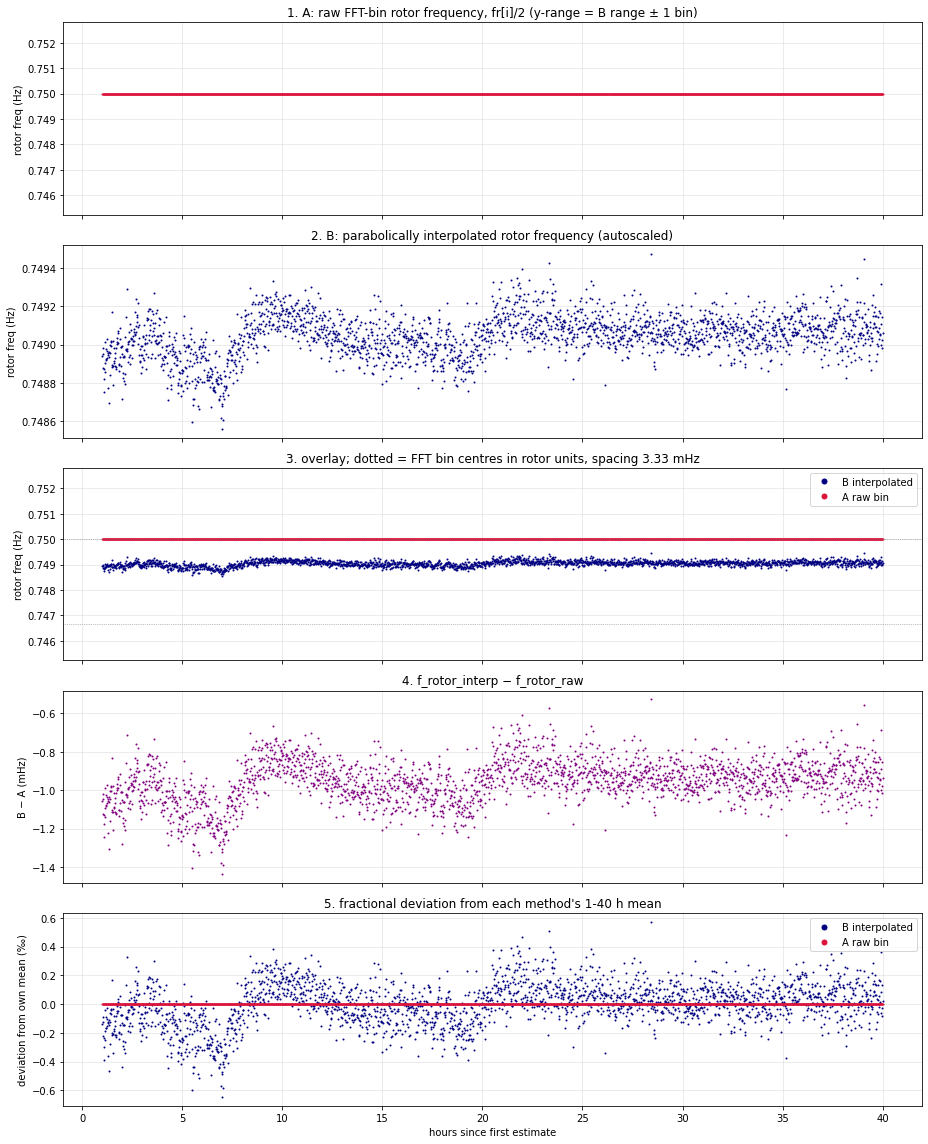

In [7]:
fig, ax = plt.subplots(5, 1, figsize=(13, 16), sharex=True)
lim = (fB.min() - DF_ROT, fB.max() + DF_ROT)          # one bin either side of B's range
bins = np.arange(np.floor(lim[0]/DF_ROT), np.ceil(lim[1]/DF_ROT) + 1)*DF_ROT

ax[0].plot(h11, fA, '.', ms=2, color='crimson'); ax[0].set_ylim(lim)
ax[0].set_title('1. A: raw FFT-bin rotor frequency, fr[i]/2 (y-range = B range ± 1 bin)')
ax[1].plot(h11, fB, '.', ms=2, color='navy')
ax[1].set_title('2. B: parabolically interpolated rotor frequency (autoscaled)')
ax[2].plot(h11, fB, '.', ms=2, color='navy', label='B interpolated')
ax[2].plot(h11, fA, '.', ms=2, color='crimson', label='A raw bin')
for fk in bins: ax[2].axhline(fk, color='gray', lw=0.7, ls=':')
ax[2].set_ylim(lim); ax[2].legend(loc='upper right', markerscale=5)
ax[2].set_title(f'3. overlay; dotted = FFT bin centres in rotor units, spacing {DF_ROT*1e3:.2f} mHz')
for a in ax[:3]: a.set_ylabel('rotor freq (Hz)')

ax[3].plot(h11, dAB*1e3, '.', ms=2, color='purple')
ax[3].set_ylabel('B − A (mHz)'); ax[3].set_title('4. f_rotor_interp − f_rotor_raw')
ax[4].plot(h11, (fB/fB.mean() - 1)*1e3, '.', ms=2, color='navy', label='B interpolated')
ax[4].plot(h11, (fA/fA.mean() - 1)*1e3, '.', ms=2, color='crimson', label='A raw bin')
ax[4].set_ylabel('deviation from own mean (‰)'); ax[4].legend(loc='upper right', markerscale=5)
ax[4].set_title(f'5. fractional deviation from each method\'s {WIN_H[0]}-{WIN_H[1]} h mean')
ax[4].set_xlabel('hours since first estimate')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

**One window's spectrum.** Dots: FFT bins. Line: ×16 zero-padded, the continuous spectrum the bins
sample. A = tallest bin. B = vertex of a parabola through it and its neighbours: an estimate of the
continuous peak, *assuming one isolated Hann-shaped line*. No added Fourier resolution: lines
< ~1 bin apart still merge. Right: the four scales on one axis.

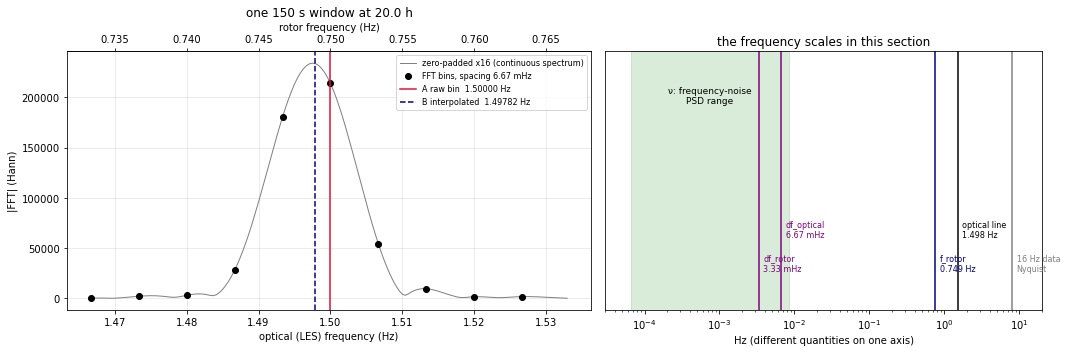

In [8]:
j = np.argmin(abs(H_ALL - 20))                         # one window at 20 h
i0 = int(round((T[j] - WIN/2 - t16[0])*fs16))
seg = y16[i0:i0+nw]; seg = (seg - seg.mean())*np.hanning(nw)
fr_b, X_b = np.fft.rfftfreq(nw, 1/fs16), np.abs(np.fft.rfft(seg))
fr_z, X_z = np.fft.rfftfreq(16*nw, 1/fs16), np.abs(np.fft.rfft(seg, 16*nw))
fraw_j, fint_j, _ = peak_in_band(y16[i0:i0+nw], fs16, 1.27, 1.65)

fig, ax = plt.subplots(1, 2, figsize=(15, 5), gridspec_kw=dict(width_ratios=[1.2, 1]))
w = (fr_b > fraw_j - 5*DF_OPT) & (fr_b < fraw_j + 5*DF_OPT)
wz = (fr_z > fraw_j - 5*DF_OPT) & (fr_z < fraw_j + 5*DF_OPT)
ax[0].plot(fr_z[wz], X_z[wz], color='gray', lw=1, label='zero-padded x16 (continuous spectrum)')
ax[0].plot(fr_b[w], X_b[w], 'o', color='k', label=f'FFT bins, spacing {DF_OPT*1e3:.2f} mHz')
ax[0].axvline(fraw_j, color='crimson', lw=1.5, label=f'A raw bin  {fraw_j:.5f} Hz')
ax[0].axvline(fint_j, color='navy', lw=1.5, ls='--', label=f'B interpolated  {fint_j:.5f} Hz')
ax[0].set_xlabel('optical (LES) frequency (Hz)'); ax[0].set_ylabel('|FFT| (Hann)')
ax[0].set_title(f'one 150 s window at {H_ALL[j]:.1f} h'); ax[0].legend(fontsize=8); ax[0].grid(alpha=.3)
sec = ax[0].secondary_xaxis('top', functions=(lambda x: x/DIVISOR, lambda x: x*DIVISOR))
sec.set_xlabel('rotor frequency (Hz)')

NPS_NU = 256                                           # Welch segment for the PSD below (as in section 3)
nu_lo, nu_hi = 1/(NPS_NU*STEP), 1/(2*STEP)
ax[1].axvspan(nu_lo, nu_hi, color='green', alpha=0.15)
ax[1].text(np.sqrt(nu_lo*nu_hi), 0.8, 'ν: frequency-noise\nPSD range', ha='center', fontsize=9)
marks = [(DF_ROT, 'df_rotor\n3.33 mHz', 'purple'), (DF_OPT, 'df_optical\n6.67 mHz', 'purple'),
         (fB.mean(), 'f_rotor\n0.749 Hz', 'navy'), (fB.mean()*DIVISOR, 'optical line\n1.498 Hz', 'k'),
         (fs16/2, '16 Hz data\nNyquist', 'gray')]
for k, (x, lab, c) in enumerate(marks):
    ax[1].axvline(x, color=c, lw=1.5); ax[1].text(x*1.15, 0.15 + 0.13*(k % 2), lab, fontsize=8, color=c)
ax[1].set_xscale('log'); ax[1].set_xlim(3e-5, 20); ax[1].set_ylim(0, 1); ax[1].set_yticks([])
ax[1].set_xlabel('Hz (different quantities on one axis)'); ax[1].set_title('the frequency scales in this section')
plt.tight_layout(); plt.show()

**Synthetic check.** Pure tones through the same `peak_in_band`, stepped across one bin:
1. bias of B vs position in the bin;
2. gain dB/d(true) (1 = sub-bin shifts reported at true size);
3. scatter of B from white noise at the measured median SNR.

Model: one stationary tone + white noise. Harmonics, AM and non-white motion near the line are not simulated.

observed B offset -0.286 bins -> true offset -0.338 bins, bias there +0.0517 bins = +0.172 mHz rotor (constant; shifts the mean only)
gain dB/dtrue: 1.07 at the operating point, 1.00..1.15 over ±1σ, 0.86..1.42 over the full 1-40 h range
A for a pure tone: bin 225 for every true offset in (-0.5, 0.5) -> constant 0.7500 Hz rotor
white noise at SNR 541 (measured median 546): B scatter 0.0038 mHz rotor vs observed B std 0.1121 mHz (30x larger)


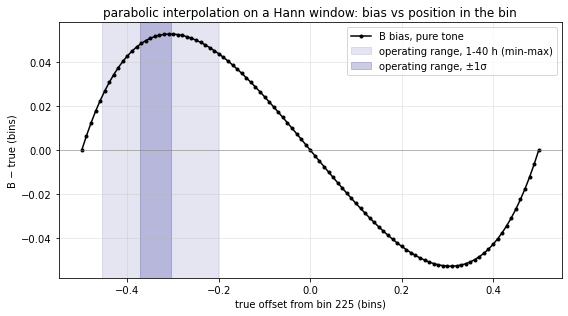

In [9]:
tt = np.arange(nw)/fs16
k0 = int(round(fA.mean()*DIVISOR/DF_OPT))            # A's bin index (225 -> 1.500 Hz optical)
band = (1.50*0.85, 1.50*1.10)
def est_B(d, noise=0.0, n=8, rng=None):
    """mean and std of B (optical Hz) for a tone at bin k0+d, averaged over n phases / noise draws"""
    out = []
    for p in np.linspace(0, 2*np.pi, n, endpoint=False):
        x = np.sin(2*np.pi*(k0 + d)*DF_OPT*tt + p)
        if noise: x = x + noise*rng.standard_normal(nw)
        out.append(peak_in_band(x, fs16, *band)[1:])
    out = np.array(out)
    return out[:, 0].mean(), out[:, 0].std(), np.median(out[:, 1])

d_true = np.linspace(-0.5, 0.5, 101)
bias = np.array([(est_B(d)[0] - (k0 + d)*DF_OPT)/DF_OPT for d in d_true])

# operating point: the true offset whose (biased) B matches the observed mean B offset
d_obs = dAB.mean()/DF_ROT
d_op = np.interp(d_obs, d_true + bias, d_true)
gain = 1 + np.gradient(bias, d_true)                  # dB/dtrue: how a real sub-bin shift is reported
d_lo, d_hi = (np.interp(v/DF_ROT, d_true + bias, d_true) for v in (dAB.min(), dAB.max()))
d_1s = d_op + np.array([-1, 1])*dAB.std()/DF_ROT
g_1s = np.interp(d_1s, d_true, gain); g_all = gain[(d_true >= d_lo) & (d_true <= d_hi)]

rng = np.random.default_rng(0)
_, _, snr0 = est_B(d_op, noise=0.03, n=50, rng=rng)
sig = 0.03*snr0/np.median(SNR[mref])                  # noise level giving the measured median SNR
_, sdB, snr_sim = est_B(d_op, noise=sig, n=300, rng=rng)
sd_noise = sdB/DIVISOR                                 # rotor Hz

print(f'observed B offset {d_obs:+.3f} bins -> true offset {d_op:+.3f} bins, '
      f'bias there {np.interp(d_op, d_true, bias):+.4f} bins = '
      f'{np.interp(d_op, d_true, bias)*DF_ROT*1e3:+.3f} mHz rotor (constant; shifts the mean only)')
print(f'gain dB/dtrue: {np.interp(d_op, d_true, gain):.2f} at the operating point, '
      f'{g_1s.min():.2f}..{g_1s.max():.2f} over ±1σ, {g_all.min():.2f}..{g_all.max():.2f} over the full 1-40 h range')
print(f'A for a pure tone: bin {k0} for every true offset in (-0.5, 0.5) -> constant {k0*DF_ROT:.4f} Hz rotor')
print(f'white noise at SNR {snr_sim:.0f} (measured median {np.median(SNR[mref]):.0f}): '
      f'B scatter {sd_noise*1e3:.4f} mHz rotor vs observed B std {fB.std()*1e3:.4f} mHz '
      f'({fB.std()/sd_noise:.0f}x larger)')

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(d_true, bias, 'k.-', label='B bias, pure tone')
ax.axvspan(d_lo, d_hi, color='navy', alpha=0.1, label='operating range, 1-40 h (min-max)')
ax.axvspan(*d_1s, color='navy', alpha=0.2, label='operating range, ±1σ')
ax.axhline(0, color='gray', lw=0.5)
ax.set_xlabel(f'true offset from bin {k0} (bins)'); ax.set_ylabel('B − true (bins)')
ax.set_title('parabolic interpolation on a Hann window: bias vs position in the bin')
ax.legend(); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

**PSD of each estimator.** δf = f − mean(1–40 h); Welch, fs from timestamps (60 s, Nyquist 8.3 mHz),
nperseg 256, `detrend=False`. Dotted: white floor of the simulated estimator scatter (2σ²/fs), a model.

second-stage sampling: fs = 1/60.0 s = 1.667e-02 Hz, Nyquist 8.33 mHz, nperseg 256 -> resolution 65.1 µHz
  A raw bin      : var 0.000e+00 Hz², integral of PSD 0.000e+00 Hz², max S 0.000e+00 Hz²/Hz
  B interpolated : var 1.256e-08 Hz², integral of PSD 1.099e-08 Hz², max S 4.196e-05 Hz²/Hz


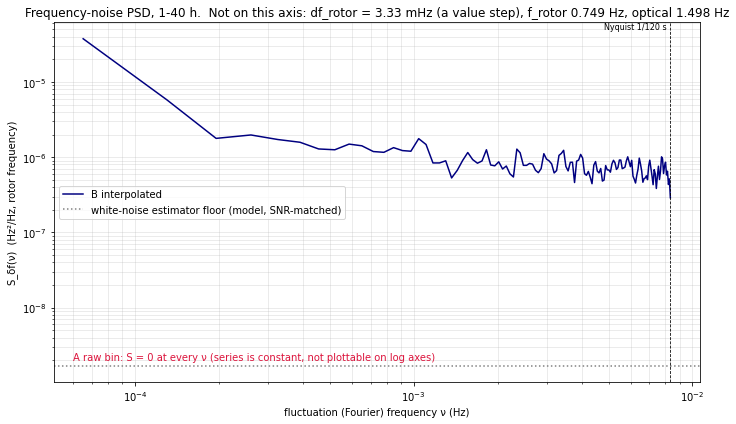

In [10]:
dtA = np.diff(T[mref])
fs_nu = 1/np.median(dtA)
assert np.allclose(dtA, 1/fs_nu), 'uneven cadence in 1-40 h: Welch needs an even grid'
print(f'second-stage sampling: fs = 1/{1/fs_nu:.1f} s = {fs_nu:.3e} Hz, Nyquist {fs_nu/2*1e3:.2f} mHz, '
      f'nperseg {NPS_NU} -> resolution {fs_nu/NPS_NU*1e6:.1f} µHz')

S = {}
for name, f in (('A raw bin', fA), ('B interpolated', fB)):
    nu, S[name] = welch(f - f.mean(), fs=fs_nu, nperseg=NPS_NU, detrend=False)
    print(f'  {name:15s}: var {np.var(f):.3e} Hz², integral of PSD {np.trapz(S[name], nu):.3e} Hz²,'
          f' max S {S[name].max():.3e} Hz²/Hz')

fig, ax = plt.subplots(figsize=(10, 6))
ax.loglog(nu[1:], S['B interpolated'][1:], color='navy', label='B interpolated')
if (S['A raw bin'][1:] > 0).any():
    ax.loglog(nu[1:], S['A raw bin'][1:], color='crimson', label='A raw bin')
else:
    ax.text(0.03, 0.06, 'A raw bin: S = 0 at every ν (series is constant, not plottable on log axes)',
            transform=ax.transAxes, color='crimson')
ax.axhline(2*sd_noise**2/fs_nu, color='gray', ls=':', label='white-noise estimator floor (model, SNR-matched)')
ax.axvline(fs_nu/2, color='k', lw=0.8, ls='--'); ax.text(fs_nu/2*0.97, ax.get_ylim()[1], 'Nyquist 1/120 s',
                                                         ha='right', va='top', fontsize=8)
ax.set_xlabel('fluctuation (Fourier) frequency ν (Hz)')
ax.set_ylabel('S_δf(ν)  (Hz²/Hz, rotor frequency)')
ax.set_title(f'Frequency-noise PSD, {WIN_H[0]}-{WIN_H[1]} h.  Not on this axis: '
             f'df_rotor = {DF_ROT*1e3:.2f} mHz (a value step), f_rotor 0.749 Hz, optical 1.498 Hz')
ax.legend(); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

**Result (1–40 h):**
- **A is constant:** bin 225 (0.75000 Hz rotor) in every window. B's wander (std 0.11 mHz) spans
  ~0.07 bin, ~0.29 bin below bin 225, never near a bin edge. B − A (RMS 0.96, max 1.44 mHz) is
  mostly the constant offset.
- So B − A and the PSD difference measure A's quantisation, not estimator sensitivity. Zero from A
  doesn't mean no wander; non-zero B doesn't by itself prove it real.
- **Synthetic check:** the interpolation doesn't create the wander (white-noise scatter ~0.004 mHz,
  30× below observed). It does scale it: gain 1.07 at the operating point, 1.00–1.15 over ±1σ,
  0.86–1.42 at the extremes (~0.75 at a bin centre). The constant bias, +0.05 bin (+0.17 mHz;
  true mean ≈ 0.74888 Hz), cancels in δf.
- **Not covered:** frequency change within a window, AM, non-white motion near 1.5 Hz. A fully
  independent check would track the line's phase.

### 1.4 Window length: 150 / 300 / 600 s (robustness check only)

Same tracker at WIN = 150, 300, 600 s, STEP = 60 s; the 150 s run must reproduce `FR` exactly.

**One change for 300/600 s:** the band is centred on the 150 s estimate at the same time. Left
self-tracking, they lose the 1.498 Hz line during spin-up and lock onto the 3× (2.247 Hz) and
4× (2.996 Hz) rotation harmonics. Band width and `peak_in_band` unchanged.

δf = f − mean(1–40 h) removes constant offsets. Timestamps are window centres (offsets 75 s, 225 s);
1–40 h is the same absolute stretch for all three.

**Longer windows low-pass the track** (and overlap up to 90%), so less high-ν power at long WIN is
expected and is not a better measurement. The test is agreement at hour scales (ν ≤ 1/3600 s).

In [11]:
def track_rotor(win, step=STEP, guide=False):
    """The §1.1 tracking loop at window length win. Returns (T, f_raw, f_interp), rotor Hz.
    guide=True centres the band on the 150 s track (FR) at the window centre instead of on
    this window's own last estimate -- the only change, needed to stay on the 1.498 Hz line."""
    nw_, sw_ = int(win*fs16), int(step*fs16)
    rows_, trk = [], 1.50
    for i in range(0, len(y16)-nw_, sw_):
        tc = t16[i] + win/2
        if guide: trk = np.interp(tc, T, FR)*DIVISOR
        fraw, fpk, snr = peak_in_band(y16[i:i+nw_], fs16, max(trk*0.85, 0.02), trk*1.10)
        if np.isnan(fpk) or fpk <= 0: continue
        rows_.append((tc, fraw/DIVISOR, fpk/DIVISOR))
        trk = fpk
    return map(np.array, zip(*rows_))

WINS = (150, 300, 600)
WCOL = {150: 'navy', 300: 'darkorange', 600: 'forestgreen'}
N_RM = int(round(1800/STEP))                            # 30 min running mean, as in 6.1
TRK = {}
print(f"{'WIN':>5} | {'df_optical':>10} | {'df_rotor':>10} | {'N':>5} | {'mean f (Hz)':>11} | "
      f"{'std δf (mHz)':>12} | {'std 30-min mean (mHz)':>21} | {'sub-bin offset':>14} | {'interp gain':>11}")
for w in WINS:
    Tw, Rw, Fw = track_rotor(w, guide=(w != 150))
    m = ((Tw - T_REF)/3600 >= WIN_H[0]) & ((Tw - T_REF)/3600 <= WIN_H[1])
    d = Fw[m] - Fw[m].mean()
    TRK[w] = dict(t=Tw[m], h=(Tw[m] - T_REF)/3600, f=Fw[m], d=d,
                  rm=uniform_filter1d(d, N_RM, mode='nearest'))
    dfo = fs16/int(w*fs16)
    off = ((Fw[m] - Rw[m])/(dfo/DIVISOR)).mean()             # observed B offset from the peak bin, in bins
    g = np.interp(np.interp(off, d_true + bias, d_true), d_true, gain)   # 1.3 pure-tone gain at that offset
    print(f'{w:5d} | {dfo:10.6f} | {dfo/DIVISOR:10.6f} | {m.sum():5d} | {Fw[m].mean():11.6f} | '
          f'{d.std()*1e3:12.4f} | {TRK[w]["rm"].std()*1e3:21.4f} | {off:+14.3f} | {g:11.2f}')
assert np.array_equal(TRK[150]['f'], FR[mref]) and np.array_equal(TRK[150]['t'], T[mref]), \
    '150 s re-run does not reproduce FR'
print('(Hz; df_optical = 1/WIN, df_rotor = 1/(2 WIN).)  150 s re-run reproduces FR exactly.')
print('sub-bin offset = mean interpolation offset (bins); interp gain = dB/d(true) there, from the 1.3 pure-tone check')

# slow structure: compare the 30 min running means on the 150 s time grid
print('\n30 min running means vs 150 s (interpolated onto the 150 s timestamps):')
for w in WINS[1:]:
    rm_w = np.interp(TRK[150]['t'], TRK[w]['t'], TRK[w]['rm'])
    r = np.corrcoef(TRK[150]['rm'], rm_w)[0, 1]
    print(f'  {w} s: correlation {r:.3f}, std of difference {(rm_w - TRK[150]["rm"]).std()*1e3:.4f} mHz')

  WIN | df_optical |   df_rotor |     N | mean f (Hz) | std δf (mHz) | std 30-min mean (mHz) | sub-bin offset | interp gain
  150 |   0.006667 |   0.003333 |  2341 |    0.749046 |       0.1121 |                0.0755 |         -0.286 |        1.07
  300 |   0.003333 |   0.001667 |  2340 |    0.748793 |       0.0892 |                0.0702 |         +0.276 |        1.04
  600 |   0.001667 |   0.000833 |  2340 |    0.748910 |       0.0936 |                0.0832 |         -0.237 |        0.97
(Hz; df_optical = 1/WIN, df_rotor = 1/(2 WIN).)  150 s re-run reproduces FR exactly.
sub-bin offset = mean interpolation offset (bins); interp gain = dB/d(true) there, from the 1.3 pure-tone check

30 min running means vs 150 s (interpolated onto the 150 s timestamps):
  300 s: correlation 0.996, std of difference 0.0087 mHz
  600 s: correlation 0.997, std of difference 0.0097 mHz


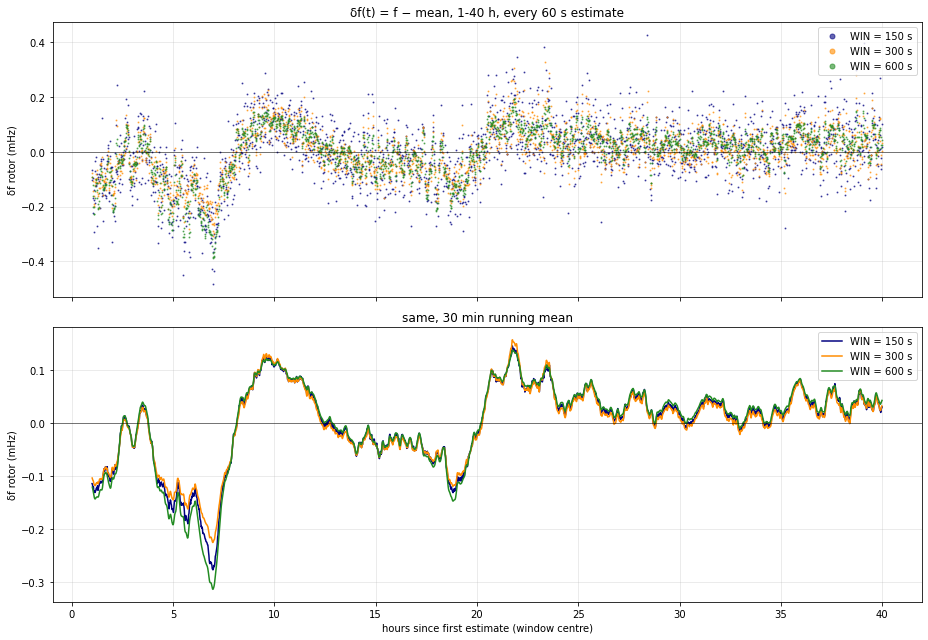

In [12]:
fig, ax = plt.subplots(2, 1, figsize=(13, 9), sharex=True)
for w in WINS:
    ax[0].plot(TRK[w]['h'], TRK[w]['d']*1e3, '.', ms=2, color=WCOL[w], alpha=0.6, label=f'WIN = {w} s')
    ax[1].plot(TRK[w]['h'], TRK[w]['rm']*1e3, color=WCOL[w], lw=1.5, label=f'WIN = {w} s')
ax[0].set_title(f'δf(t) = f − mean, {WIN_H[0]}-{WIN_H[1]} h, every 60 s estimate')
ax[1].set_title('same, 30 min running mean')
for a in ax:
    a.axhline(0, color='k', lw=0.5); a.set_ylabel('δf rotor (mHz)'); a.grid(alpha=.3)
    a.legend(loc='upper right', markerscale=5)
ax[1].set_xlabel('hours since first estimate (window centre)')
plt.tight_layout(); plt.show()

Welch: fs = 1/60 s, nperseg 256, detrend=False (as in 1.3)
hour-scale band 0 < ν ≤ 1/3600 s: bins at 65, 130, 195, 260 µHz
  WIN | mean S, hour-scale (Hz²/Hz) | ratio to 150 s | per-bin ratios to 150 s
  150 |                   1.174e-05 |          1.000 | 1.00  1.00  1.00  1.00
  300 |                   1.005e-05 |          0.856 | 0.85  0.84  0.95  0.86
  600 |                   1.406e-05 |          1.198 | 1.21  1.19  1.08  1.11


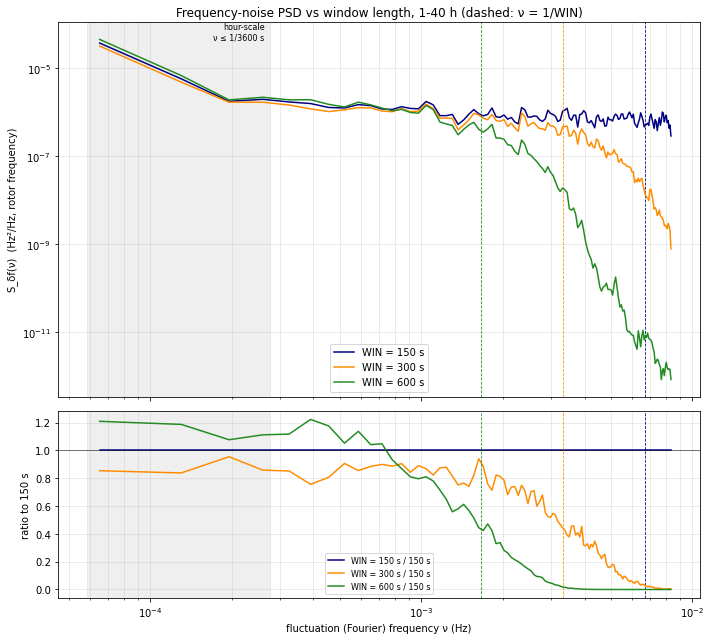

In [13]:
S_w = {}
for w in WINS:
    dt_w = np.diff(TRK[w]['t'])
    assert np.allclose(dt_w, STEP), f'uneven cadence at WIN = {w} s'
    nu_w, S_w[w] = welch(TRK[w]['d'], fs=1/STEP, nperseg=NPS_NU, detrend=False)
NU_HR = 1/3600
hr = (nu_w > 0) & (nu_w <= NU_HR)
print(f'Welch: fs = 1/{STEP:.0f} s, nperseg {NPS_NU}, detrend=False (as in 1.3)')
print(f'hour-scale band 0 < ν ≤ 1/3600 s: bins at {", ".join(f"{v*1e6:.0f}" for v in nu_w[hr])} µHz')
print(f"{'WIN':>5} | {'mean S, hour-scale (Hz²/Hz)':>27} | {'ratio to 150 s':>14} | {'per-bin ratios to 150 s'}")
for w in WINS:
    print(f'{w:5d} | {S_w[w][hr].mean():27.3e} | {S_w[w][hr].mean()/S_w[150][hr].mean():14.3f} | '
          + '  '.join(f'{x:.2f}' for x in S_w[w][hr]/S_w[150][hr]))

fig, ax = plt.subplots(2, 1, figsize=(10, 9), sharex=True, gridspec_kw=dict(height_ratios=[2, 1]))
for w in WINS:
    ax[0].loglog(nu_w[1:], S_w[w][1:], color=WCOL[w], label=f'WIN = {w} s')
    ax[1].semilogx(nu_w[1:], S_w[w][1:]/S_w[150][1:], color=WCOL[w], label=f'WIN = {w} s / 150 s')
    for a in ax: a.axvline(1/w, color=WCOL[w], lw=0.8, ls='--')
for a in ax:
    a.axvspan(nu_w[1]*0.9, NU_HR, color='gray', alpha=0.12)
    a.grid(alpha=.3, which='both')
ax[0].text(NU_HR*0.95, ax[0].get_ylim()[1], 'hour-scale\nν ≤ 1/3600 s', ha='right', va='top', fontsize=8)
ax[0].set_ylabel('S_δf(ν)  (Hz²/Hz, rotor frequency)'); ax[0].legend()
ax[0].set_title(f'Frequency-noise PSD vs window length, {WIN_H[0]}-{WIN_H[1]} h (dashed: ν = 1/WIN)')
ax[1].axhline(1, color='k', lw=0.5); ax[1].set_ylabel('ratio to 150 s'); ax[1].legend(fontsize=8)
ax[1].set_xlabel('fluctuation (Fourier) frequency ν (Hz)')
plt.tight_layout(); plt.show()

**Result (1–40 h):**
- **Hour-scale structure agrees:** 30 min running means correlate at 0.996 (300 s) and 0.997 (600 s)
  with 150 s; difference std ~0.01 mHz vs 0.07–0.08 mHz of structure. Largest disagreement: the
  5–7 h dip, ~0.04 mHz deeper at 600 s.
- **Hour-scale PSD within ±20%** (0.86×, 1.20×; ±10% in amplitude). Not monotonic in WIN and not
  explained by the operating-point gains (1.07, 1.04, 0.97). Recorded, not explained.
- **Above ~1 mHz the PSDs separate:** window filtering (600 s from ~1 mHz, 300 s from ~2 mHz).
  Less bandwidth, not less rotor noise.
- **For σ_f(T):** WIN changes the result by ≲10% for T ≳ 1 h; at shorter T it sets the result.

### 1.5 Rotor frequency-noise PSD (primary)

Used from here on:
- time series: `FR` (150 s, interpolated); the 300/600 s runs are not used;
- δf(t) = FR(t) − f0, f0 = mean over 1–40 h, in Hz;
- S_δf(ν) in Hz²/Hz: Welch, fs from timestamps, nperseg 256, `detrend=False`.

f0 (mean rotor frequency, 1-40 h) = 0.749046 Hz
std of delta_f                     = 1.121e-04 Hz = 0.1121 mHz
sampling interval                  = 60.0 s  (fs = 1.6667e-02 Hz)
duration used                      = 2341 estimates x 60 s = 39.02 h
lowest nonzero Fourier frequency   = 6.510e-05 Hz  (period 4.27 h)
Nyquist frequency                  = 8.333e-03 Hz  (period 2 min)


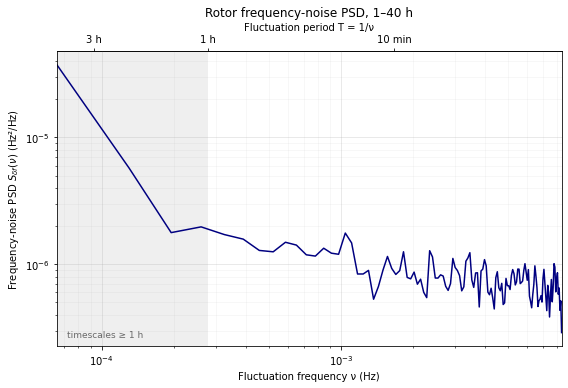

In [14]:
t_p, f_p = T[mref], FR[mref]                           # 150 s tracker, 1-40 h (no re-run)
f0 = f_p.mean()
delta_f = f_p - f0                                      # Hz
dt_p = np.diff(t_p)
assert np.allclose(dt_p, dt_p[0]), 'uneven cadence: Welch needs an even grid'
fs_p = 1/np.median(dt_p)
nu_p, S_df = welch(delta_f, fs=fs_p, nperseg=NPS_NU, detrend=False)

print(f'f0 (mean rotor frequency, {WIN_H[0]}-{WIN_H[1]} h) = {f0:.6f} Hz')
print(f'std of delta_f                     = {delta_f.std():.3e} Hz = {delta_f.std()*1e3:.4f} mHz')
print(f'sampling interval                  = {1/fs_p:.1f} s  (fs = {fs_p:.4e} Hz)')
print(f'duration used                      = {len(delta_f)} estimates x {1/fs_p:.0f} s = {len(delta_f)/fs_p/3600:.2f} h')
print(f'lowest nonzero Fourier frequency   = {nu_p[1]:.3e} Hz  (period {1/nu_p[1]/3600:.2f} h)')
print(f'Nyquist frequency                  = {fs_p/2:.3e} Hz  (period {2/fs_p/60:.0f} min)')

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(nu_p[1:], S_df[1:], color='navy', lw=1.5)
ax.set_xlim(nu_p[1], fs_p/2)
ax.axvspan(nu_p[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.text(0.02, 0.03, 'timescales ≥ 1 h', transform=ax.transAxes, fontsize=9, color='dimgray')
ax.set_xlabel('Fluctuation frequency ν (Hz)')
ax.set_ylabel('Frequency-noise PSD $S_{\\delta f}(\\nu)$ (Hz²/Hz)')
ax.set_title(f'Rotor frequency-noise PSD, {WIN_H[0]}–{WIN_H[1]} h')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12)

def inv(x):
    with np.errstate(divide='ignore'): return 1/x      # matplotlib probes x = 0 when building the axis
top = ax.secondary_xaxis('top', functions=(inv, inv))
per = [(600, '10 min'), (3600, '1 h'), (3*3600, '3 h')]    # 10 h is below the lowest ν (~4.3 h)
top.set_xticks([p for p, _ in per]); top.set_xticklabels([l for _, l in per])
top.xaxis.set_minor_locator(plt.NullLocator())
top.set_xlabel('Fluctuation period T = 1/ν')
plt.tight_layout(); plt.show()

## 2. Pb-212 decay timescale in Fourier space

Where in ν the 10.6 h half-life sits. **Shape only:** no force, torque, I or δf amplitude is assumed.

A(t) = 2^(−t/T½), A0 = 1, on the 1–40 h timestamps of `FR` (t = 0 at the start of the interval;
that choice only rescales A and cancels in the normalisation). Spectral estimate as in §1.5: the
1–40 h mean subtracted (as for δf), Welch, same fs, nperseg 256, `detrend=False`. Normalised by its
maximum over ν > 0.

Pb-212 half-life              = 10.6 h
mean lifetime tau = T½/ln 2   = 15.29 h   (decay rate 1/(2π tau) = 2.89e-06 Hz)
duration analysed             = 2341 x 60 s = 39.02 h
lowest nonzero ν              = 6.510e-05 Hz  (period 4.27 h)
Nyquist                       = 8.333e-03 Hz  (period 2 min)


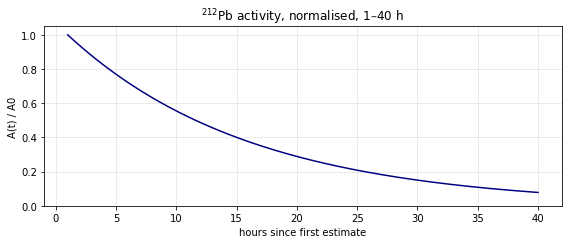

In [15]:
T_HALF_H = 10.6                                  # Pb-212 half-life (h)
TAU_PB_H = T_HALF_H/np.log(2)                   # mean lifetime (h)
t_pb = (t_p - t_p[0])/3600                       # h, the 1-40 h timestamps of FR (1.5)
A_pb = 2**(-t_pb/T_HALF_H)                       # A0 = 1, dimensionless

nu_pb, P_pb = welch(A_pb - A_pb.mean(), fs=fs_p, nperseg=NPS_NU, detrend=False)
P_norm = P_pb[1:]/P_pb[1:].max()

print(f'Pb-212 half-life              = {T_HALF_H:.1f} h')
print(f'mean lifetime tau = T½/ln 2   = {TAU_PB_H:.2f} h   (decay rate 1/(2π tau) = {1/(2*np.pi*TAU_PB_H*3600):.2e} Hz)')
print(f'duration analysed             = {len(t_pb)} x {1/fs_p:.0f} s = {len(t_pb)/fs_p/3600:.2f} h')
print(f'lowest nonzero ν              = {nu_pb[1]:.3e} Hz  (period {1/nu_pb[1]/3600:.2f} h)')
print(f'Nyquist                       = {fs_p/2:.3e} Hz  (period {2/fs_p/60:.0f} min)')

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(H_ALL[mref], A_pb, color='navy', lw=1.5)
ax.set_xlabel('hours since first estimate'); ax.set_ylabel('A(t) / A0')
ax.set_title('$^{212}$Pb activity, normalised, 1–40 h')
ax.set_ylim(0, 1.05); ax.grid(alpha=.3); plt.tight_layout(); plt.show()

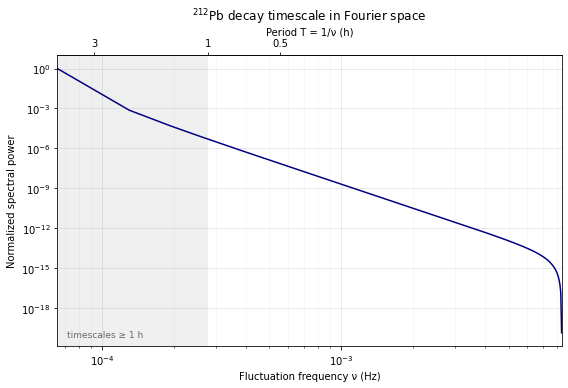

In [16]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ax.loglog(nu_pb[1:], P_norm, color='navy', lw=1.5)
ax.set_xlim(nu_pb[1], fs_p/2)
ax.axvspan(nu_pb[1], 1/3600, color='gray', alpha=0.12, lw=0)
ax.text(0.02, 0.03, 'timescales ≥ 1 h', transform=ax.transAxes, fontsize=9, color='dimgray')
ax.set_xlabel('Fluctuation frequency ν (Hz)')
ax.set_ylabel('Normalized spectral power')
ax.set_title('$^{212}$Pb decay timescale in Fourier space')
ax.grid(which='major', alpha=0.35); ax.grid(which='minor', alpha=0.12)

def nu_to_h(x):
    with np.errstate(divide='ignore'): return 1/(3600*x)
top = ax.secondary_xaxis('top', functions=(nu_to_h, nu_to_h))
top.set_xticks([0.5, 1, 3]); top.set_xticklabels(['0.5', '1', '3'])
top.xaxis.set_minor_locator(plt.NullLocator())
top.set_xlabel('Period T = 1/ν (h)')
plt.tight_layout(); plt.show()

**Interpretation.**
- A normalised spectral **shape**, not a predicted signal: no units, no amplitude.
- The 10.6 h decay (τ = 15.3 h) sets the slow time dependence of the expected recoil signal. Its
  natural rate, 1/(2πτ) ≈ 2.9e-6 Hz, is below the lowest ν here (6.5e-5 Hz, set by the 4.27 h Welch
  segment) and below even 1/(39 h) ≈ 7e-6 Hz for the full record.
- So within this analysis the decay is a slow drift: 99.9% of its power falls in the lowest bin, and
  essentially all of it at ν ≤ 1/(1 h). The ν⁻⁶ fall-off above that is the Hann window's sidelobe
  roll-off, not a property of the decay; no Pb-212 spectral feature is resolved in this band.
- The absolute Pb-212 recoil spectrum (Hz²/Hz) comes later, after converting the expected recoil
  force/torque into a rotor-frequency response.

## 3. Thermal noise floor

Fluctuation–dissipation limit from gas damping alone:
$S_\Omega(\nu) = 4k_BT\gamma / [I(\gamma^2 + (2\pi\nu)^2)]$, ASD in Hz/√Hz = √S_Ω / 2π.
Uses only I, γ = 1/τ and T_bath.

The table compares it with the measured ASD of the linearly detrended 1–40 h `FR` (September's
method, Welch at 60 s cadence), not yet with the §1.5 PSD.

In [17]:
t_res = T[mref] - T[mref][0]                     # linearly detrended 1-40 h FR (same as sigma_f_table in 4)
resid = FR[mref] - np.polyval(np.polyfit(t_res, FR[mref], 1), t_res)

def thermal_asd_f(f):
    return np.sqrt(4*KB_J*T_BATH*GAMMA/(I_TOTAL*(GAMMA**2 + (2*np.pi*f)**2)))/(2*np.pi)

dt_tr = np.median(np.diff(t_res)); fs_tr = 1/dt_tr
NPS = 256
f_tr, P_f = welch(resid, fs=fs_tr, nperseg=NPS)
asd_f = np.sqrt(P_f)
print(f"{'freq':>10} | {'measured':>10} | {'thermal':>10} | x thermal")
for fr in (1.3e-4, 1e-3, 5e-3):
    j = np.argmin(abs(f_tr - fr))
    print(f'{f_tr[j]*1e3:8.3f}mHz | {asd_f[j]:10.3e} | {thermal_asd_f(f_tr[j]):10.3e} | {asd_f[j]/thermal_asd_f(f_tr[j]):6.0f}x')

      freq |   measured |    thermal | x thermal
   0.130mHz |  2.385e-03 |  8.087e-05 |     29x
   0.977mHz |  1.095e-03 |  1.112e-05 |     98x
   5.013mHz |  8.230e-04 |  2.168e-06 |    380x


## 4. Sensitivity: σ_f(T) → minimum torque and force

σ_f(T) = std of T-long block means of the linearly detrended `FR` over 1–40 h
(`sensitivity_20260911.ipynb` §3–4). Frequency-channel threshold:

$$\Delta\tau_{\min}(T) = \frac{2\pi I\,\gamma\,N_\sigma\,\sigma_f(T)}{1 - e^{-\gamma T}},\qquad
F_{\min} = \Delta\tau_{\min}/r$$

(force on one wing at lever arm r). **First table = regression check:** September's settings
(I = 1.7e-11, r = 1.88 mm, 1–45 h) must give 18.15 fN at 1 h and 6.96 fN at 4 h.

REGRESSION (Sept settings: I=1.7e-11, r=1.88 mm, 1-45 h)
   T=    60 s  F=  884.39 fN
   T=   300 s  F=  165.98 fN
   T=   600 s  F=   84.33 fN
   T=  1800 s  F=   31.18 fN
   T=  3600 s  F=   18.15 fN
   T=  7200 s  F=   11.51 fN
   T= 14400 s  F=    6.96 fN
   -> matches sensitivity_20260911 (18.15 fN @1 h, 6.96 fN @4 h)

THIS NOTEBOOK: I=1.88e-11, tau=79.8 min, window 1-40 h, resid std 0.1064 mHz
      T | sigma_f (Hz) | dtau_min (N m) | F @1.38 mm (fN) | F @1.88 mm (fN)
     60 |    1.064e-04 |      1.054e-15 |          763.56 |          560.48
    300 |    7.773e-05 |      1.579e-16 |          114.40 |           83.97
    600 |    7.210e-05 |      7.551e-17 |           54.72 |           40.17
   1800 |    6.645e-05 |      2.616e-17 |           18.96 |           13.91
   3600 |    6.287e-05 |      1.467e-17 |           10.63 |            7.80
   7200 |    5.445e-05 |      8.637e-18 |            6.26 |            4.59
  14400 |    4.919e-05 |      6.383e-18 |            4.63 |      

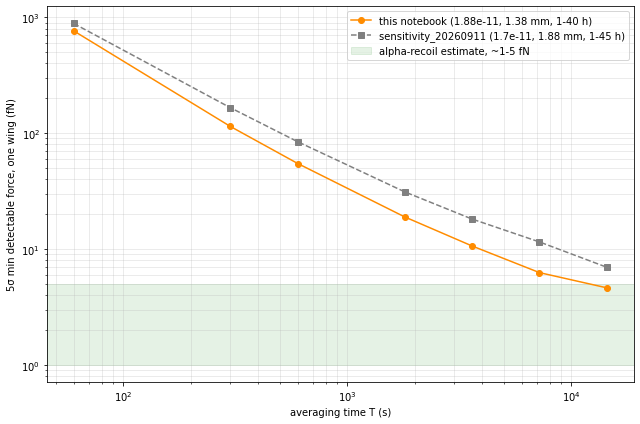

In [18]:
T_AVGS = np.array([60, 300, 600, 1800, 3600, 7200, 14400])

def window(h0, h1):
    m = (H_ALL >= h0) & (H_ALL <= h1)
    t = T[m] - T[m][0]
    return m, t

def sigma_f_table(h0, h1):
    m, t = window(h0, h1)
    r = FR[m] - np.polyval(np.polyfit(t, FR[m], 1), t)
    dt = np.median(np.diff(t)); out = []
    for Ta in T_AVGS:
        n = max(1, int(round(Ta/dt))); nb = len(r)//n
        out.append(r[:nb*n].reshape(nb, n).mean(1).std() if nb >= 4 else np.nan)
    return np.array(out), r, t

def min_torque(sf):
    return 2*np.pi*I_TOTAL*GAMMA*NSIG*sf / (1 - np.exp(-GAMMA*T_AVGS))

# --- regression check against sensitivity_20260911 ---
sf_sep, _, _ = sigma_f_table(1, 45)
F_sep = 2*np.pi*1.7e-11*GAMMA*NSIG*sf_sep/(1-np.exp(-GAMMA*T_AVGS)) / 1.88e-3
print('REGRESSION (Sept settings: I=1.7e-11, r=1.88 mm, 1-45 h)')
for Ta, F in zip(T_AVGS, F_sep): print(f'   T={Ta:6d} s  F={F*1e15:8.2f} fN')
assert abs(F_sep[4]*1e15 - 18.15) < 0.05 and abs(F_sep[6]*1e15 - 6.96) < 0.05, 'regression failed'
print('   -> matches sensitivity_20260911 (18.15 fN @1 h, 6.96 fN @4 h)\n')

# --- this notebook's numbers ---
sf, resid, t_res = sigma_f_table(*WIN_H)
dtau = min_torque(sf)
print(f'THIS NOTEBOOK: I={I_TOTAL:.2e}, tau={TAU_S/60:.1f} min, window {WIN_H[0]}-{WIN_H[1]} h, '
      f'resid std {resid.std()*1e3:.4f} mHz')
print(f"{'T':>7} | {'sigma_f (Hz)':>12} | {'dtau_min (N m)':>14} | {'F @1.38 mm (fN)':>15} | {'F @1.88 mm (fN)':>15}")
for Ta, s, d in zip(T_AVGS, sf, dtau):
    print(f'{Ta:>7d} | {s:12.3e} | {d:14.3e} | {d/R_EFF*1e15:15.2f} | {d/R_TIP*1e15:15.2f}')
print(f'\nI systematic: with I = {I_ALT:.1e} every torque/force number is x{I_ALT/I_TOTAL:.3f}.')

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(T_AVGS, dtau/R_EFF*1e15, 'o-', color='darkorange', label='this notebook (1.88e-11, 1.38 mm, 1-40 h)')
ax.loglog(T_AVGS, F_sep*1e15, 's--', color='gray', label='sensitivity_20260911 (1.7e-11, 1.88 mm, 1-45 h)')
ax.axhspan(1, 5, color='green', alpha=0.1, label='alpha-recoil estimate, ~1-5 fN')
ax.set_xlabel('averaging time T (s)'); ax.set_ylabel(f'{NSIG:.0f}σ min detectable force, one wing (fN)')
ax.legend(); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

## 5. Laser RIN (fractional)

RIN = (PD − dark)/mean. As in `laser_dark_vs_on.ipynb`: 1 Hz series, one global linear detrend,
Welch with 10 000 s segments (0.1 mHz resolution, trusted above ~0.3 mHz). **Dark baseline:** same
PD with the laser off, from the spindown right after the hold (dataset 2, +700 s on), so alignment
and electronics are unchanged; expressed as RIN at the same operating level.

ON level 473.84 counts, dark 1.794 -> signal 472.04 counts; 39.0 h
averages: ON ~27, DARK ~11

      band (mHz) | RIN ON (/rtHz) | DARK (/rtHz) | ON/DARK
   0.30-    1.0 |       3.39e-02 |     1.50e-03 |   22.6x
   1.00-    3.0 |       2.45e-03 |     7.91e-04 |    3.1x
   3.00-   10.0 |       7.46e-04 |     5.77e-04 |    1.3x
  10.00-  100.0 |       2.30e-04 |     1.53e-04 |    1.5x
 100.00-  500.0 |       7.38e-05 |     4.18e-05 |    1.8x


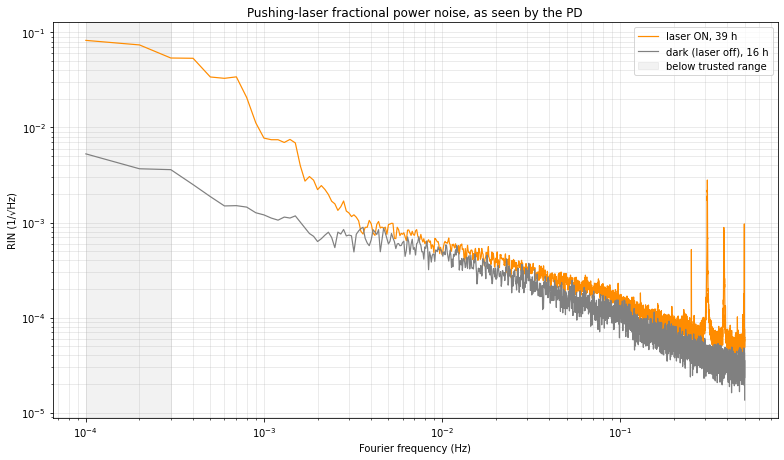

In [19]:
m1 = (tpd1 - T_REF >= WIN_H[0]*3600) & (tpd1 - T_REF < WIN_H[1]*3600)
on = pd1[m1].astype(float)
P0 = on.mean() - DARK_LEVEL
print(f'ON level {on.mean():.2f} counts, dark {DARK_LEVEL:.3f} -> signal {P0:.2f} counts; {len(on)/3600:.1f} h')

SEG_LO_S = 10000
def asd_lowf(y, fs=1.0, seg_s=SEG_LO_S):
    ts = np.arange(len(y))/fs
    yd = y - np.polyval(np.polyfit(ts, y, 1), ts)
    f, P = welch(yd, fs=fs, nperseg=int(seg_s*fs))
    return f, np.sqrt(P), len(y)/(seg_s*fs/2) - 1

f_r, a_on, n_on = asd_lowf(on)
_, a_dk, n_dk = asd_lowf(dark)
rin_on, rin_dk = a_on/P0, a_dk/P0
print(f'averages: ON ~{n_on:.0f}, DARK ~{n_dk:.0f}\n')

BANDS = [(3e-4,1e-3),(1e-3,3e-3),(3e-3,1e-2),(1e-2,1e-1),(0.1,0.5)]
print(f"{'band (mHz)':>16} | {'RIN ON (/rtHz)':>14} | {'DARK (/rtHz)':>12} | ON/DARK")
for lo, hi in BANDS:
    b = (f_r > lo) & (f_r < hi)
    r1, r2 = np.median(rin_on[b]), np.median(rin_dk[b])
    print(f'{lo*1e3:7.2f}-{hi*1e3:7.1f} | {r1:14.2e} | {r2:12.2e} | {r1/r2:6.1f}x')

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.loglog(f_r[1:], rin_on[1:], color='darkorange', lw=1.2, label=f'laser ON, {len(on)/3600:.0f} h')
ax.loglog(f_r[1:], rin_dk[1:], color='gray', lw=1.2, label=f'dark (laser off), {len(dark)/3600:.0f} h')
ax.axvspan(1e-4, 3e-4, color='gray', alpha=0.1, label='below trusted range')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('RIN (1/√Hz)')
ax.set_title('Pushing-laser fractional power noise, as seen by the PD')
ax.legend(); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

### 5.1 Requirement: three candidates (not yet adopted)

PI's logic (`laser_dark_vs_on.ipynb`): laser power noise enters as torque through the same response
as thermal torque, so the requirement is laser torque noise = thermal torque noise, flat in ν:
RIN_req = √(4k_BTγI) / (torque per mW × P). The candidates differ only in torque per mW:

- **(A) steady state, no calibration:** laser torque = drag torque Iγ·2πf₀, so
  RIN_req = √(4k_BTγI) / (Iγ·2πf₀). Uses only I, τ, f₀; assumes k = 1.
- **(B) PI's number:** 0.735 µW/√Hz at the chamber, as RIN at 5.8 mW. Uses κ_PD = 7.35e-16 N·m/count
  and 16.2 counts/mW (July step-down, τ = 67.65 min); `apparatus_log.md` flags both as July-only.
  Implies a laser torque 3.7× the drag torque here.
- **(C) 09-15 step-down slope, 1030 → 1010 counts** (§8; Δf_ss ≈ 21 mHz). A band because ΔP isn't
  measured: strict edge = commanded counts (11.87 µW/count), lax edge = step-down PD (suspect).
  Provisional; it is the local slope at 1030–1010, not at 1300.

(B) and (C) as RIN need the 5.8 mW calibration; (A) doesn't. §6 measures |k| < 0.033, so each line
answers "*if* the PD wander reached the sail as torque, would it matter?"; §7 uses the measured k.

thermal torque ASD 8.066e-18 N m/rtHz (tau = 79.8 min); drag torque at f0 = 0.74905 Hz: 1.848e-14 N m
(C): df_ss = 21.05 mHz over dP = 237 uW (commanded) / 395 uW (PD)

                         candidate | torque/mW (N m) | req (uW/rtHz) | RIN req (/rtHz)
     (A) steady-state ratio, k = 1 |        3.19e-15 |          2.53 |        4.36e-04
                (B) PI, July kappa |        1.19e-14 |          0.68 |        1.17e-04
 (C) step 1030->1010, commanded dP |        2.19e-15 |          3.69 |        6.36e-04
        (C) step 1030->1010, PD dP |        1.32e-15 |          6.13 |        1.06e-03

(B) implies a laser torque at 5.8 mW of 6.91e-14 N m = 3.7x the drag torque

      band (mHz) |    RIN ON | x req (A) | x req (B) |    x req (C)
   0.30-    1.0 |  3.39e-02 |     77.7x |    290.6x |  32.1-53.4x
   1.00-    3.0 |  2.45e-03 |      5.6x |     20.9x |   2.3- 3.8x
   3.00-   10.0 |  7.46e-04 |      1.7x |      6.4x |   0.7- 1.2x
  10.00-  100.0 |  2.30e-04 |      0.5x |      2.0x 

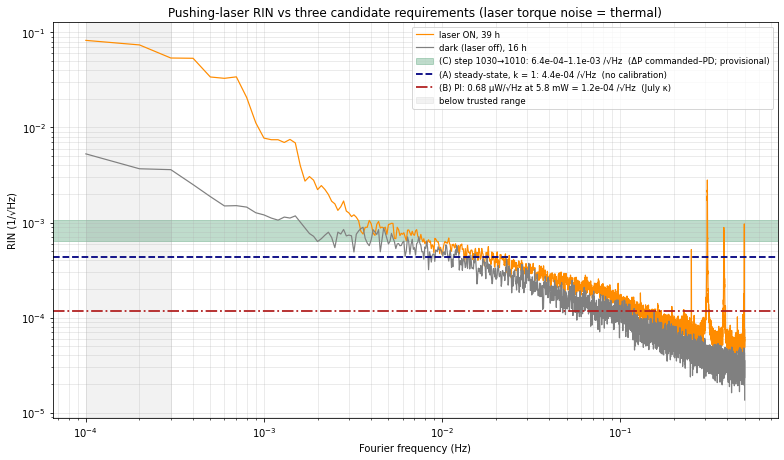

In [20]:
# Three candidate requirements on the same RIN plot (see markdown above) -- for choosing, not yet adopted
mR, _ = window(*WIN_H)
f0_hold = FR[mR].mean()
S_N_TH = np.sqrt(4*KB_J*T_BATH*GAMMA*I_TOTAL)       # thermal torque ASD, N m/rtHz
N_HOLD = I_TOTAL*GAMMA*2*np.pi*f0_hold              # drag torque at f0 = the laser torque, if the laser holds the rotor
P_CHAMBER_MW = 5.8                                  # LASER_OFFSET 1300 (dataset notes) -- itself a power calibration

# (A) calibration-free: torque per mW = steady-state ratio N_HOLD / P (k = 1)
TPM_A = N_HOLD/P_CHAMBER_MW
# (B) PI / laser_dark_vs_on: kappa_PD 7.35e-16 N m/count x 16.2 cts/mW (July step-down, tau 67.65 min -> 0.735 uW/rtHz)
TPM_B = 7.3499e-16*167.6/10.34
# (C) slope from the 09-15 step-down, 1030 -> 1010 (the only clean, large, plateaued pair; §8 table)
st = pd.read_csv('stepdown_20260914_steps.csv').drop_duplicates('offset').set_index('offset')
df_step = st.loc[1030, 'f_ss'] - st.loc[1010, 'f_ss']
dP_cmd = 20*11.87e-3                                # mW: commanded counts x 11.87 uW/count (apparatus_log, "still good")
dP_pd = (360.62 - 329.09)/463.23*P_CHAMBER_MW       # mW: step-down PD means (stepdown_20260914 §4); 463 cts at 1300
TPM_C = np.array([I_TOTAL*GAMMA*2*np.pi*df_step/dP for dP in (dP_cmd, dP_pd)])   # N m/mW, [commanded, PD]

rin_req = lambda tpm: S_N_TH/tpm/P_CHAMBER_MW       # laser torque noise = thermal  ->  RIN at this run's power
RIN_REQ_SS, RIN_REQ_PI, RIN_REQ_C = rin_req(TPM_A), rin_req(TPM_B), rin_req(TPM_C)

print(f'thermal torque ASD {S_N_TH:.3e} N m/rtHz (tau = {TAU_S/60:.1f} min); drag torque at f0 = {f0_hold:.5f} Hz: {N_HOLD:.3e} N m')
print(f'(C): df_ss = {df_step*1e3:.2f} mHz over dP = {dP_cmd*1e3:.0f} uW (commanded) / {dP_pd*1e3:.0f} uW (PD)\n')
print(f"{'candidate':>34} | {'torque/mW (N m)':>15} | {'req (uW/rtHz)':>13} | {'RIN req (/rtHz)':>15}")
for name, tpm in [('(A) steady-state ratio, k = 1', TPM_A), ('(B) PI, July kappa', TPM_B),
                  ('(C) step 1030->1010, commanded dP', TPM_C[0]), ('(C) step 1030->1010, PD dP', TPM_C[1])]:
    print(f'{name:>34} | {tpm:15.2e} | {S_N_TH/tpm*1e3:13.2f} | {rin_req(tpm):15.2e}')
print(f'\n(B) implies a laser torque at {P_CHAMBER_MW} mW of {TPM_B*P_CHAMBER_MW:.2e} N m = {TPM_B*P_CHAMBER_MW/N_HOLD:.1f}x the drag torque\n')

def crossing(req, nsm=9):
    """Lowest trusted frequency where the (running-median) ON RIN falls below req."""
    sm = np.array([np.median(rin_on[max(i-nsm//2, 0):i+nsm//2+1]) for i in range(len(rin_on))])
    ok = (f_r > 3e-4) & (sm < req)
    return f_r[ok][0] if ok.any() else np.nan

print(f"{'band (mHz)':>16} | {'RIN ON':>9} | {'x req (A)':>9} | {'x req (B)':>9} | {'x req (C)':>12}")
for lo, hi in BANDS:
    b = (f_r > lo) & (f_r < hi); r1 = np.median(rin_on[b])
    print(f'{lo*1e3:7.2f}-{hi*1e3:7.1f} | {r1:9.2e} | {r1/RIN_REQ_SS:8.1f}x | {r1/RIN_REQ_PI:8.1f}x | '
          f'{r1/RIN_REQ_C[1]:5.1f}-{r1/RIN_REQ_C[0]:4.1f}x')
print(f'\nON RIN falls below (A) above ~{crossing(RIN_REQ_SS)*1e3:.1f} mHz, (B) above ~{crossing(RIN_REQ_PI)*1e3:.1f} mHz, '
      f'(C, strict edge) above ~{crossing(RIN_REQ_C[0])*1e3:.1f} mHz')

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.loglog(f_r[1:], rin_on[1:], color='darkorange', lw=1.2, label=f'laser ON, {len(on)/3600:.0f} h')
ax.loglog(f_r[1:], rin_dk[1:], color='gray', lw=1.2, label=f'dark (laser off), {len(dark)/3600:.0f} h')
ax.axhspan(*RIN_REQ_C, color='seagreen', alpha=0.3,
           label=f'(C) step 1030→1010: {RIN_REQ_C[0]:.1e}–{RIN_REQ_C[1]:.1e} /√Hz  (ΔP commanded–PD; provisional)')
ax.axhline(RIN_REQ_SS, color='navy', ls='--', lw=1.8,
           label=f'(A) steady-state, k = 1: {RIN_REQ_SS:.1e} /√Hz  (no calibration)')
ax.axhline(RIN_REQ_PI, color='firebrick', ls='-.', lw=1.8,
           label=f'(B) PI: {S_N_TH/TPM_B*1e3:.2f} µW/√Hz at {P_CHAMBER_MW} mW = {RIN_REQ_PI:.1e} /√Hz  (July κ)')
ax.axvspan(1e-4, 3e-4, color='gray', alpha=0.1, label='below trusted range')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('RIN (1/√Hz)')
ax.set_title('Pushing-laser RIN vs three candidate requirements (laser torque noise = thermal)')
ax.legend(fontsize=8.5); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

### 5.2 Does the power wander average down?

Boxcar-smoothed, detrended fractional std vs the white-noise prediction (`laser_dark_vs_on.ipynb` §6).
Ratio ≫ 1 means correlated wander.

In [21]:
print(f"{'boxcar':>7} | {'fractional std':>14} | {'white pred.':>11} | ratio")
for mins in [1, 5, 10, 30, 60, 120, 240]:
    n = mins*60
    sm = uniform_filter1d(on, n)[n//2:-n//2]
    ts = np.arange(len(sm)); sm = sm - np.polyval(np.polyfit(ts, sm, 1), ts)
    meas, pred = sm.std()/P0, on.std()/P0/np.sqrt(n)
    print(f'{mins:5d} m | {meas:14.2e} | {pred:11.2e} | {meas/pred:5.0f}x')
print(f'\nfor comparison, rotor fractional frequency std at 1 h: {sf[4]/FR[window(*WIN_H)[0]].mean():.2e}')

 boxcar | fractional std | white pred. | ratio
    1 m |       2.23e-03 |    3.06e-04 |     7x
    5 m |       2.21e-03 |    1.37e-04 |    16x
   10 m |       2.16e-03 |    9.69e-05 |    22x
   30 m |       1.94e-03 |    5.59e-05 |    35x
   60 m |       1.77e-03 |    3.95e-05 |    45x
  120 m |       1.59e-03 |    2.80e-05 |    57x
  240 m |       1.46e-03 |    1.98e-05 |    74x

for comparison, rotor fractional frequency std at 1 h: 8.39e-05


## 6. Correlation: does the PD wander show up in the rotor frequency?

If torque follows power, $\frac{\delta f}{f}(\omega) = k\,\frac{1}{1 + i\omega\tau}\,\frac{\delta P}{P}(\omega)$;
k is the DC gain (k = 1 for torque ∝ power, linear drag, no other torques). Both series share the
tracker's 150 s windows (PD averaged over the same windows, §1.1).

### 6.1 Frequency and PD on the same fractional scale

Deviation from each series' own 1–40 h mean, in ‰, on one axis (the raw axes span ~1% vs ~170%).
Top: whole file (the PD slide after 40.5 h and the 45.5 h jump run off-scale; the first hour is
spin-up). Bottom: 1–40 h, 30 min running mean, the timescale where a laser effect would appear
after the ~80 min rotor response.

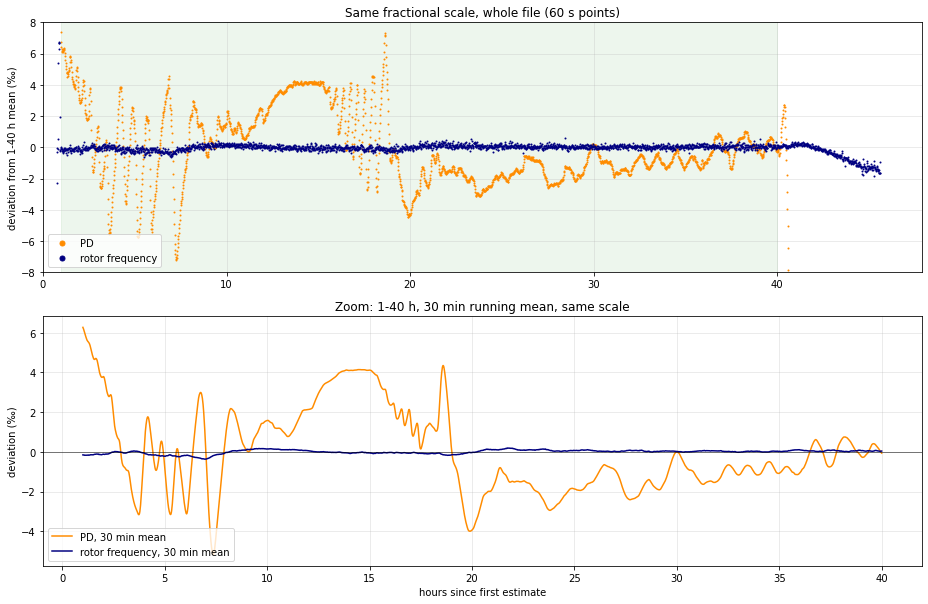

In [22]:
f_ref, p_ref = FR[mref].mean(), PDW[mref].mean() - DARK_LEVEL
dfr = (FR/f_ref - 1)*1e3                        # permil
dpd = ((PDW - DARK_LEVEL)/p_ref - 1)*1e3

fig, ax = plt.subplots(2, 1, figsize=(13, 8.5))
ax[0].plot(H_ALL, dpd, '.', ms=2, color='darkorange', label='PD')
ax[0].plot(H_ALL, dfr, '.', ms=2, color='navy', label='rotor frequency')
ax[0].axvspan(*WIN_H, color='green', alpha=0.07)
ax[0].set_ylim(-8, 8); ax[0].set_xlim(0, H_ALL.max())
ax[0].set_ylabel('deviation from 1-40 h mean (‰)')
ax[0].set_title('Same fractional scale, whole file (60 s points)')
ax[0].legend(loc='lower left', markerscale=5)

N30 = int(round(1800/np.median(np.diff(T))))
h_w = H_ALL[mref]
sm = lambda z: uniform_filter1d(z, N30, mode='nearest')
ax[1].plot(h_w, sm(dpd[mref]), color='darkorange', lw=1.5, label='PD, 30 min mean')
ax[1].plot(h_w, sm(dfr[mref]), color='navy', lw=1.5, label='rotor frequency, 30 min mean')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_ylabel('deviation (‰)'); ax[1].set_xlabel('hours since first estimate')
ax[1].set_title(f'Zoom: {WIN_H[0]}-{WIN_H[1]} h, 30 min running mean, same scale')
ax[1].legend(loc='lower left')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

In [23]:
print(f'1-40 h, 30 min means: PD std {sm(dpd[mref]).std():.2f} ‰, frequency std {sm(dfr[mref]).std():.3f} ‰ '
      f'(ratio {sm(dpd[mref]).std()/sm(dfr[mref]).std():.0f}x)')

1-40 h, 30 min means: PD std 2.12 ‰, frequency std 0.101 ‰ (ratio 21x)


### 6.2 DC gain k: matched fit

Both series linearly detrended over 1–40 h. δP/P is passed through the model (k = 1) and
least-squares scaled onto δf/f. Null: circular PD shifts ≥ 4 h (breaks any link, keeps each series'
colour). An injection test checks that a known k is recovered. (Replaces the planned coherence
estimator; see §6.3.)

In [24]:
mW, tW = window(*WIN_H)
def det(z): return z - np.polyval(np.polyfit(tW, z, 1), tW)
x = det((PDW[mW] - DARK_LEVEL)/P0)            # fractional power
y = det(FR[mW]/FR[mW].mean())                 # fractional frequency
dtW = np.median(np.diff(tW))

def response(xx, tau_s=TAU_S):
    a = dtW/tau_s
    return lfilter([a], [1, -(1-a)], xx)

def k_matched(xx, yy, tau_s=TAU_S):
    u = det(response(xx, tau_s))
    return np.dot(u, yy)/np.dot(u, u)

rng = np.random.default_rng(1)
SHIFTS = rng.integers(240, len(x) - 240, 2000)          # >= 4 h at 60 s cadence
k0 = k_matched(x, y)
null = np.array([k_matched(np.roll(x, s), y) for s in SHIFTS])
lo95, hi95 = np.percentile(null - null.mean(), [2.5, 97.5])
K_UL = max(abs(k0 - null.mean() + lo95), abs(k0 - null.mean() + hi95))
print(f'k (tau = {TAU_S/60:.1f} min) = {k0:+.4f} ± {null.std():.4f}   '
      f'({(k0-null.mean())/null.std():+.1f} σ from the shift-null)')
print(f'95% interval for k: [{k0-null.mean()+lo95:+.4f}, {k0-null.mean()+hi95:+.4f}]  ->  |k| < {K_UL:.3f}')

print('\ninjection test (y + k_true * model response to the measured PD):')
for kt in [0.01, 0.03, 0.1, 0.3, 1.0]:
    k_rec = k_matched(x, y + det(kt*response(x)))
    print(f'   k_true = {kt:5.2f} -> recovered {k_rec:+.4f}   (expected {k0+kt:+.4f})')

print('\nrobustness to the assumed response time:')
for tm in [5, 20, 44, 79.8, 160]:
    kk = k_matched(x, y, tm*60)
    nn = np.array([k_matched(np.roll(x, s), y, tm*60) for s in SHIFTS[:500]])
    print(f'   tau = {tm:5.1f} min: k = {kk:+.4f} ± {nn.std():.4f}')

print(f'\nfor scale: measured δf/f std {y.std():.2e}; predicted std if k = 1: {det(response(x)).std():.2e}')

k (tau = 79.8 min) = -0.0105 ± 0.0143   (-0.9 σ from the shift-null)
95% interval for k: [-0.0326, +0.0149]  ->  |k| < 0.033

injection test (y + k_true * model response to the measured PD):
   k_true =  0.01 -> recovered -0.0005   (expected -0.0005)
   k_true =  0.03 -> recovered +0.0195   (expected +0.0195)
   k_true =  0.10 -> recovered +0.0895   (expected +0.0895)
   k_true =  0.30 -> recovered +0.2895   (expected +0.2895)
   k_true =  1.00 -> recovered +0.9895   (expected +0.9895)

robustness to the assumed response time:
   tau =   5.0 min: k = -0.0070 ± 0.0083
   tau =  20.0 min: k = -0.0071 ± 0.0109
   tau =  44.0 min: k = -0.0077 ± 0.0128
   tau =  79.8 min: k = -0.0105 ± 0.0144
   tau = 160.0 min: k = -0.0171 ± 0.0177

for scale: measured δf/f std 1.42e-04; predicted std if k = 1: 1.46e-03


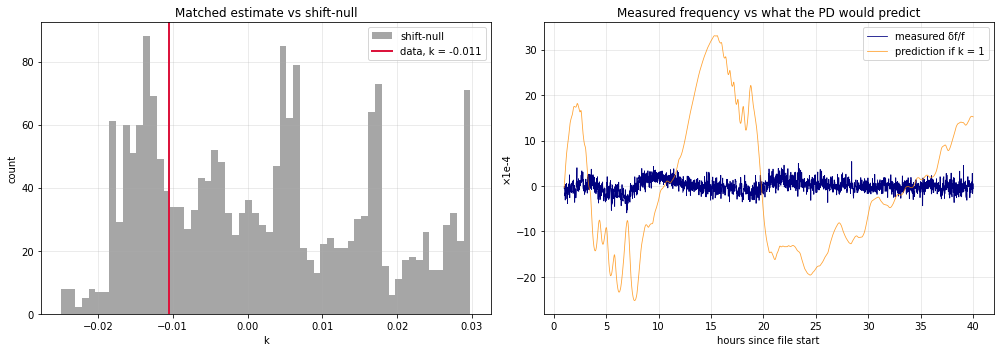

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
ax[0].hist(null, bins=60, color='gray', alpha=0.7, label='shift-null')
ax[0].axvline(k0, color='crimson', lw=2, label=f'data, k = {k0:+.3f}')
ax[0].set_xlabel('k'); ax[0].set_ylabel('count'); ax[0].legend(); ax[0].set_title('Matched estimate vs shift-null')
hh = tW/3600 + WIN_H[0]
ax[1].plot(hh, y*1e4, lw=0.8, color='navy', label='measured δf/f')
ax[1].plot(hh, det(response(x))*1e4, lw=0.8, color='darkorange', alpha=0.8, label='prediction if k = 1')
ax[1].set_xlabel('hours since file start'); ax[1].set_ylabel('×1e-4'); ax[1].legend()
ax[1].set_title('Measured frequency vs what the PD would predict')
for a in ax: a.grid(alpha=.3)
plt.tight_layout(); plt.show()

### 6.3 Coherence (diagnostic only)

The planned coherence/transfer-function estimate over 0.1–5 mHz failed the injection test: that band
is above the rotor corner (γ/2π ≈ 33 µHz), where a laser signal is suppressed by 1/(2πντ) and buried
in rotor noise. Shown, not used for k.

9 independent segments -> 95% null coherence ~ 0.31; median in 0.1-5 mHz = 0.05; bins above null: 8 of 75


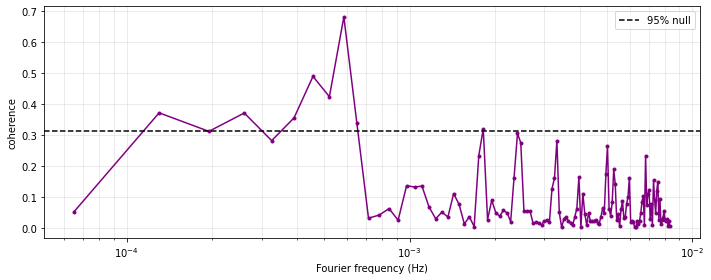

In [26]:
f_c, C = coherence(x, y, fs=1/dtW, nperseg=NPS)
n_ind = len(x)//NPS
C95 = 1 - 0.05**(1/(n_ind - 1))
band = (f_c >= 1e-4) & (f_c <= 5e-3)
print(f'{n_ind} independent segments -> 95% null coherence ~ {C95:.2f}; '
      f'median in 0.1-5 mHz = {np.median(C[band]):.2f}; bins above null: {(C[band] > C95).sum()} of {band.sum()}')
fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogx(f_c[1:], C[1:], '.-', color='purple'); ax.axhline(C95, color='k', ls='--', label='95% null')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('coherence'); ax.legend(); ax.grid(alpha=.3, which='both')
plt.tight_layout(); plt.show()

## 7. Noise projection

Rotor-frequency ASD (Hz/√Hz), 60 s grid:
- **measured:** from §3 (linearly detrended `FR`);
- **laser at the 95% upper limit on k:** |K_UL| · |1/(1+i2πντ)| · RIN · f₀, RIN from the
  window-averaged PD (same smoothing);
- **thermal:** the §3 floor.

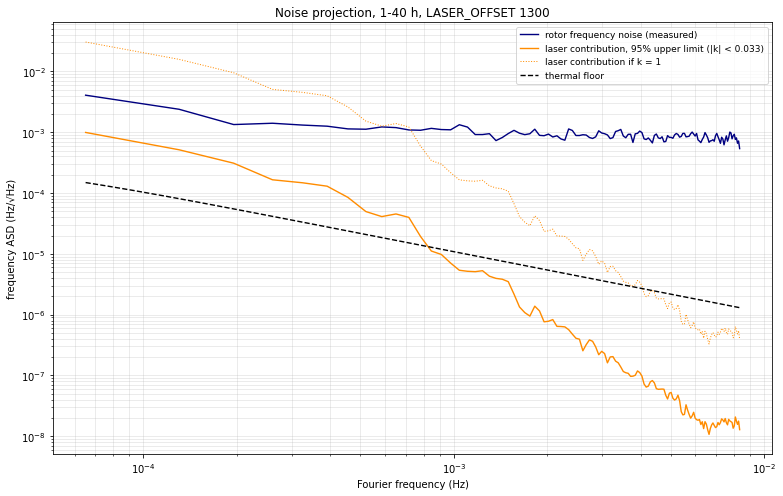

      freq |   measured | laser (UL) | laser if k=1 |    thermal
   0.130mHz |   2.38e-03 |   5.15e-04 |     1.58e-02 |   8.09e-05
   0.521mHz |   1.12e-03 |   4.96e-05 |     1.52e-03 |   2.08e-05
   0.977mHz |   1.10e-03 |   7.05e-06 |     2.16e-04 |   1.11e-05
   5.013mHz |   8.23e-04 |   5.26e-08 |     1.61e-06 |   2.17e-06


In [27]:
f0 = FR[mW].mean()
f_x, P_x = welch(x, fs=1/dtW, nperseg=NPS)
rin_w = np.sqrt(P_x)
M = np.abs(1/(1 + 2j*np.pi*f_x*TAU_S))
laser_proj = K_UL * M * rin_w * f0

fig, ax = plt.subplots(figsize=(11, 7))
ax.loglog(f_tr[1:], asd_f[1:], color='navy', lw=1.4, label='rotor frequency noise (measured)')
ax.loglog(f_x[1:], laser_proj[1:], color='darkorange', lw=1.4, label=f'laser contribution, 95% upper limit (|k| < {K_UL:.3f})')
ax.loglog(f_x[1:], (M*rin_w*f0)[1:], color='darkorange', lw=1, ls=':', label='laser contribution if k = 1')
fl = np.logspace(np.log10(f_tr[1]), np.log10(f_tr[-1]), 200)
ax.loglog(fl, thermal_asd_f(fl), 'k--', lw=1.4, label='thermal floor')
ax.set_xlabel('Fourier frequency (Hz)'); ax.set_ylabel('frequency ASD (Hz/√Hz)')
ax.set_title('Noise projection, 1-40 h, LASER_OFFSET 1300')
ax.legend(fontsize=9); ax.grid(alpha=.3, which='both'); plt.tight_layout(); plt.show()

print(f"{'freq':>10} | {'measured':>10} | {'laser (UL)':>10} | {'laser if k=1':>12} | {'thermal':>10}")
for fr in (1.3e-4, 5e-4, 1e-3, 5e-3):
    j, i = np.argmin(abs(f_tr-fr)), np.argmin(abs(f_x-fr))
    print(f'{f_tr[j]*1e3:8.3f}mHz | {asd_f[j]:10.2e} | {laser_proj[i]:10.2e} | {(M*rin_w*f0)[i]:12.2e} | {thermal_asd_f(f_tr[j]):10.2e}')

## 8. Step-down observations, 09-14/15 (reported, not interpreted)

From `stepdown_20260914_steps.csv` (`stepdown_20260914.ipynb`): same rotor, nearby operating points.
The cause is not understood, and no number here depends on it.

In [28]:
steps = pd.read_csv('stepdown_20260914_steps.csv')
print(steps[['offset', 'utc', 'f_ss', 'tau_min', 'rms_mHz', 'plateaued']].to_string(index=False))
print(f'\nfree-decay tau for comparison: {TAU_S/60:.1f} min')

 offset                  utc     f_ss    tau_min  rms_mHz  plateaued
 1300.0 2026-09-14T21:52:36Z 0.749712  22.626916 0.060024       True
 1250.0 2026-09-14T23:02:38Z 0.749503 480.000000 0.065762       True
 1200.0 2026-09-15T00:12:39Z 0.750269  21.649185 0.058791       True
 1150.0 2026-09-15T01:22:40Z 0.750432   5.790409 0.067735       True
 1100.0 2026-09-15T02:32:41Z 0.750510  18.254454 0.070418       True
 1050.0 2026-09-15T03:42:42Z 0.751010  63.136473 1.546137       True
 1040.0 2026-09-15T04:52:43Z 0.749844 479.999494 0.333297       True
 1030.0 2026-09-15T06:02:44Z 0.748393   7.206929 0.449694       True
 1020.0 2026-09-15T08:02:46Z 0.736822  44.070252 0.415704       True
 1010.0 2026-09-15T09:37:48Z 0.727340  31.943333 0.306891       True
 1000.0 2026-09-15T10:47:49Z 0.701059  30.373375 1.802495      False
 1000.0 2026-09-15T12:47:51Z 0.684193 146.330083 1.020672      False

free-decay tau for comparison: 79.8 min


Observations:
- **1300 → 1050 counts:** f_ss stays within 0.7497–0.7510 Hz while the PD drops ~18%. τ unconstrained
  (6–480 min): no step to fit.
- **1030 → 1020 → 1010:** f_ss 0.7484 → 0.7368 → 0.7273 Hz; τ 44 and 32 min (< 79.8 min free decay).
- **1000:** no plateau; the frequency keeps falling.

Consistent with §6 (no response to PD wander at 1300). Neither says why.

## 9. Conclusions

1. **Sensitivity (5σ, one wing, I = 1.88e-11, τ = 79.8 min, r = 1.38 mm, 1–40 h): ~10.6 fN at 1 h,
   ~4.6 fN at 4 h** (764 fN at 1 min). Better than September's 18 / 7 fN despite less favourable
   constants, almost entirely from dropping 40–45 h (σ_f at 1 h: 1.6e-4 → 6.3e-5 Hz).
   Systematics: ×0.90 with I = 1.7e-11; ×0.73 with the tip lever arm. The regression check
   reproduces September exactly.
2. **Rotor noise vs thermal:** 29× at 0.13 mHz, ~100× at 1 mHz, ~380× at 5 mHz. Technical-noise limited.
3. **Laser RIN (as the PD sees it):** 3.4e-2 /√Hz at 0.3–1 mHz, 23× the dark floor; doesn't average
   down (45× white at 1 h); at the dark floor above ~3 mHz. Fractional wander at 1 h: 1.8e-3 (power)
   vs 8.4e-5 (rotor frequency).
4. **Correlation: k = −0.011 ± 0.014; |k| < 0.033 (95%)**, for any assumed response time 5–160 min.
   With k = 1 the rotor would wander ~10× more than measured. The injection test recovers k.
5. **Noise projection:** at the k upper limit the laser (as the PD sees it) is below the measured rotor
   noise everywhere; it doesn't explain the rotor wander at 1300.

**Caveat.** A null k at 1300 fits either (a) the PD wander isn't power reaching the sail, or (b) the
rotor doesn't respond to torque changes at this operating point (§8). Not separable here; (b) would
affect the sensitivity, which assumes the free-decay response. Would separate them: a calibrated
torque step at 1300; an independent power monitor at the sail.

**Open:** the 40.5 h PD slide and 45.5 h jump; lab temperature as a correlation witness
(`ambient_temp_pull.py`); the imaging-beam null test.

In [29]:
print('SENSITIVITY (5σ, one wing, lever arm 1.38 mm, I = 1.88e-11, tau = 79.8 min, 1-40 h):')
for Ta, d in zip(T_AVGS, dtau):
    if Ta in (60, 3600, 14400): print(f'   {Ta/60:6.0f} min : {d/R_EFF*1e15:7.2f} fN')
print(f'   (x{I_ALT/I_TOTAL:.2f} with I = 1.7e-11; x{R_EFF/R_TIP:.2f} with the tip lever arm)')
b = (f_r > 3e-4) & (f_r < 1e-3)
print(f'LASER RIN 0.3-1 mHz: {np.median(rin_on[b]):.1e} /rtHz ({np.median(rin_on[b])/np.median(rin_dk[b]):.0f}x the dark floor)')
print(f'CORRELATION: k = {k0:+.4f} ± {null.std():.4f};  |k| < {K_UL:.3f} (95%)')

SENSITIVITY (5σ, one wing, lever arm 1.38 mm, I = 1.88e-11, tau = 79.8 min, 1-40 h):
        1 min :  763.56 fN
       60 min :   10.63 fN
      240 min :    4.63 fN
   (x0.90 with I = 1.7e-11; x0.73 with the tip lever arm)
LASER RIN 0.3-1 mHz: 3.4e-02 /rtHz (23x the dark floor)
CORRELATION: k = -0.0105 ± 0.0143;  |k| < 0.033 (95%)
